# Importar Librerias

In [1]:
!pip install -- optuna
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.6 MB/s eta 0:00:00


In [2]:
#Cargar Librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from itertools import combinations
from scipy.stats import chi2_contingency
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.pipeline import Pipeline
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
import optuna
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
    f1_score,
    balanced_accuracy_score,
    log_loss
)

# Cargar Datasets

In [3]:
#Importar dataset
df = pd.read_csv("dataset_desercion_ES_colombia.csv")

df

,id_estudiante,anio_registro,sexo,edad_ingreso,estado_civil,zona_residencia,departamento,estrato_socioeconomico,trabaja_mientras_estudia,beneficiario_icetex,...,metodologia,area_conocimiento,semestre_cursado,promedio_academico,creditos_aprobados,materias_reprobadas,doble_jornada,distancia_hogar_ies_km,puntaje_icfes_percentil,desercion
0,20,2018,Hombre,20,Union libre,Urbana,Tolima,3,1,0,...,Presencial,"Economia, administracion, contaduria y afines",3,1.85,40,1,0,6.76,74,1
1,19,2018,Hombre,20,Soltero,Rural,Valle del Cauca,1,0,0,...,Presencial,Matematicas y ciencias naturales,3,4.29,43,2,0,4.43,55,0
2,18,2018,Mujer,22,Soltero,Rural,Nariño,4,1,0,...,Presencial,Ciencias de la salud,1,2.75,15,4,1,1.77,69,1
3,17,2018,Hombre,21,Casado,Rural,Bogotá D.C.,2,0,1,...,Presencial,"Economia, administracion, contaduria y afines",2,3.07,27,1,0,55.84,30,0
4,16,2018,Hombre,19,Soltero,Urbana,Bogotá D.C.,2,1,1,...,Presencial,"Economia, administracion, contaduria y afines",1,3.90,16,2,1,2.86,23,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31562,31541,2023,Hombre,16,Soltero,Urbana,Valle del Cauca,2,0,0,...,Presencial,"Economia, administracion, contaduria y afines",4,3.00,64,2,0,6.07,40,1
31563,31542,2023,Hombre,16,Union libre,Urbana,Bogotá D.C.,4,0,0,...,Presencial,"Ingenieria, arquitectura, urbanismo y afines",4,4.87,64,0,0,21.23,15,0
31564,31543,2023,Mujer,21,Casado,Urbana,Bogotá D.C.,3,0,1,...,Presencial,Matematicas y ciencias naturales,3,3.25,48,0,0,8.02,38,0
31565,31544,2023,Mujer,18,Soltero,Urbana,Antioquia,1,1,0,...,Virtual,"Ingenieria, arquitectura, urbanismo y afines",3,4.47,48,1,1,10.52,61,0


# Analisis Dataframe

In [4]:
#Revisar la forma del dataframe
df.shape

(31567, 25)

In [5]:
#Revisar la informacion de las columnas del dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31567 entries, 0 to 31566
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_estudiante             31567 non-null  int64  
 1   anio_registro             31567 non-null  int64  
 2   sexo                      31567 non-null  object 
 3   edad_ingreso              31567 non-null  int64  
 4   estado_civil              31567 non-null  object 
 5   zona_residencia           31567 non-null  object 
 6   departamento              31567 non-null  object 
 7   estrato_socioeconomico    31567 non-null  int64  
 8   trabaja_mientras_estudia  31567 non-null  int64  
 9   beneficiario_icetex       31567 non-null  int64  
 10  beneficiario_beca         31567 non-null  int64  
 11  nivel_educativo_padre     31567 non-null  object 
 12  nivel_educativo_madre     31567 non-null  object 
 13  sector_ies                31567 non-null  object 
 14  nivel_

In [6]:
#Revisar nombres de las columnas de df
df.columns

Index(['id_estudiante', 'anio_registro', 'sexo', 'edad_ingreso',
       'estado_civil', 'zona_residencia', 'departamento',
       'estrato_socioeconomico', 'trabaja_mientras_estudia',
       'beneficiario_icetex', 'beneficiario_beca', 'nivel_educativo_padre',
       'nivel_educativo_madre', 'sector_ies', 'nivel_formacion', 'metodologia',
       'area_conocimiento', 'semestre_cursado', 'promedio_academico',
       'creditos_aprobados', 'materias_reprobadas', 'doble_jornada',
       'distancia_hogar_ies_km', 'puntaje_icfes_percentil', 'desercion'],
      dtype='object')

In [7]:
#Revisar si hay valores nulos en df
df.isnull().sum()

,0
id_estudiante,0
anio_registro,0
sexo,0
edad_ingreso,0
estado_civil,0
zona_residencia,0
departamento,0
estrato_socioeconomico,0
trabaja_mientras_estudia,0
beneficiario_icetex,0


In [8]:
#Rvisar si hay filas duplicadas en df
df.duplicated().sum()

np.int64(0)

## Analisis Variables Numericas

In [9]:
#segmentar del df solo varaibles numericas
df_numericas = df.select_dtypes(include=['int64', 'float64'])
df_numericas

,id_estudiante,anio_registro,edad_ingreso,estrato_socioeconomico,trabaja_mientras_estudia,beneficiario_icetex,beneficiario_beca,semestre_cursado,promedio_academico,creditos_aprobados,materias_reprobadas,doble_jornada,distancia_hogar_ies_km,puntaje_icfes_percentil,desercion
0,20,2018,20,3,1,0,1,3,1.85,40,1,0,6.76,74,1
1,19,2018,20,1,0,0,1,3,4.29,43,2,0,4.43,55,0
2,18,2018,22,4,1,0,0,1,2.75,15,4,1,1.77,69,1
3,17,2018,21,2,0,1,0,2,3.07,27,1,0,55.84,30,0
4,16,2018,19,2,1,1,0,1,3.90,16,2,1,2.86,23,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31562,31541,2023,16,2,0,0,0,4,3.00,64,2,0,6.07,40,1
31563,31542,2023,16,4,0,0,0,4,4.87,64,0,0,21.23,15,0
31564,31543,2023,21,3,0,1,0,3,3.25,48,0,0,8.02,38,0
31565,31544,2023,18,1,1,0,1,3,4.47,48,1,1,10.52,61,0


In [10]:
df_numericas.describe()

,id_estudiante,anio_registro,edad_ingreso,estrato_socioeconomico,trabaja_mientras_estudia,beneficiario_icetex,beneficiario_beca,semestre_cursado,promedio_academico,creditos_aprobados,materias_reprobadas,doble_jornada,distancia_hogar_ies_km,puntaje_icfes_percentil,desercion
count,31567.00000,31567.000000,31567.000000,31567.000000,31567.000000,31567.000000,31567.000000,31567.000000,31567.000000,31567.000000,31567.000000,31567.000000,31567.000000,31567.000000,31567.000000
mean,15784.00000,2020.490037,19.725124,2.644027,0.352869,0.179998,0.119999,3.874141,3.219357,58.563722,1.251307,0.315013,13.463493,45.247379,0.287135
std,9112.75231,1.682287,2.852273,1.218156,0.477870,0.384192,0.324965,2.379111,0.786389,38.343588,1.068985,0.464528,17.082530,21.492381,0.452432
min,1.00000,2018.000000,16.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.610000,0.000000,0.000000,0.000000,0.140000,1.000000,0.000000
25%,7892.50000,2019.000000,17.000000,2.000000,0.000000,0.000000,0.000000,2.000000,2.630000,28.000000,0.000000,0.000000,4.110000,30.000000,0.000000
50%,15784.00000,2021.000000,20.000000,3.000000,0.000000,0.000000,0.000000,4.000000,3.230000,52.000000,1.000000,0.000000,8.150000,45.000000,0.000000
75%,23675.50000,2022.000000,22.000000,3.000000,1.000000,0.000000,0.000000,6.000000,3.790000,87.000000,2.000000,1.000000,16.000000,60.000000,1.000000
max,31567.00000,2023.000000,33.000000,6.000000,1.000000,1.000000,1.000000,10.000000,5.000000,160.000000,8.000000,1.000000,200.000000,100.000000,1.000000


## Graficas Univariadas Numericas

### Histogramas

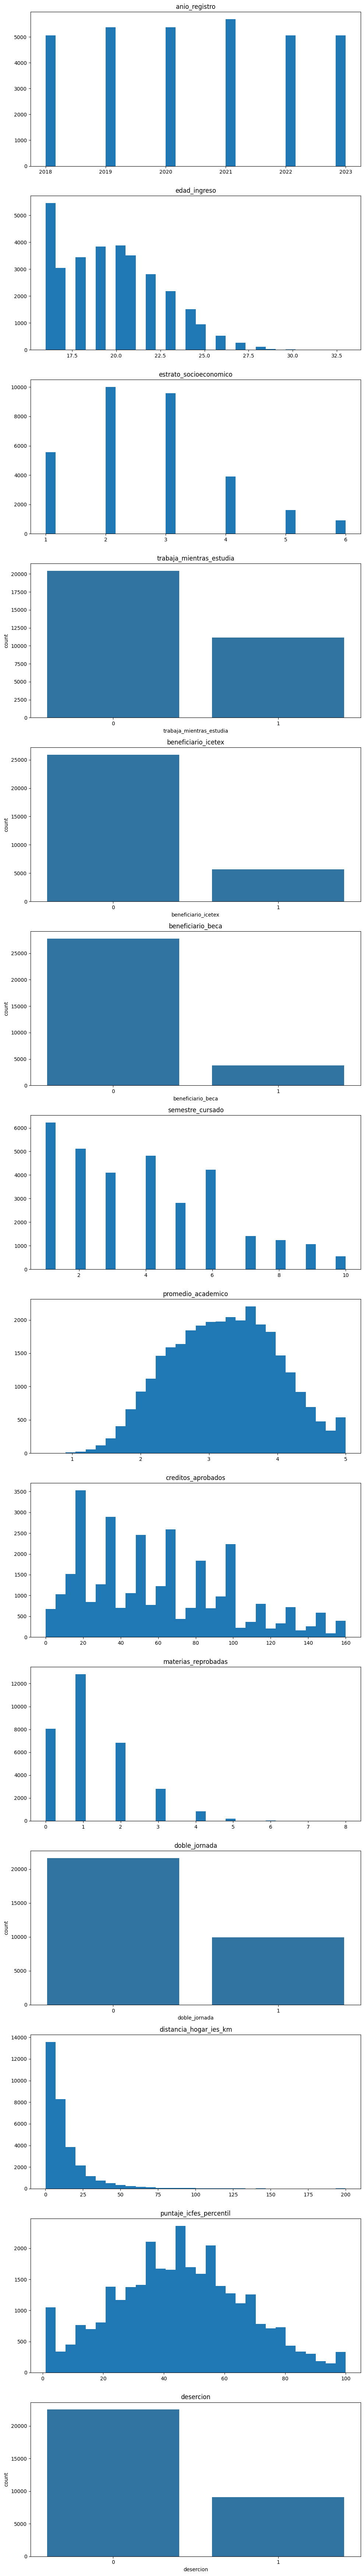

In [11]:
# 1. Identificar variables binarias (solo 0 y 1)
binarias = [col for col in df_numericas.columns if df_numericas[col].nunique() == 2]

# 2. Columnas sin id_estudiante
cols = df_numericas.drop(columns=['id_estudiante']).columns

plt.figure(figsize=(10, 5 * len(cols)))

for i, col in enumerate(cols, 1):
    plt.subplot(len(cols), 1, i)

    if col in binarias:
        # Gráfica de barras para binarias
        sns.countplot(x=df_numericas[col])
        plt.xticks([0,1])
    else:
        # Histograma para continuas
        plt.hist(df_numericas[col], bins=30)

    plt.title(col)

plt.tight_layout()
plt.show()

### Box - Plot

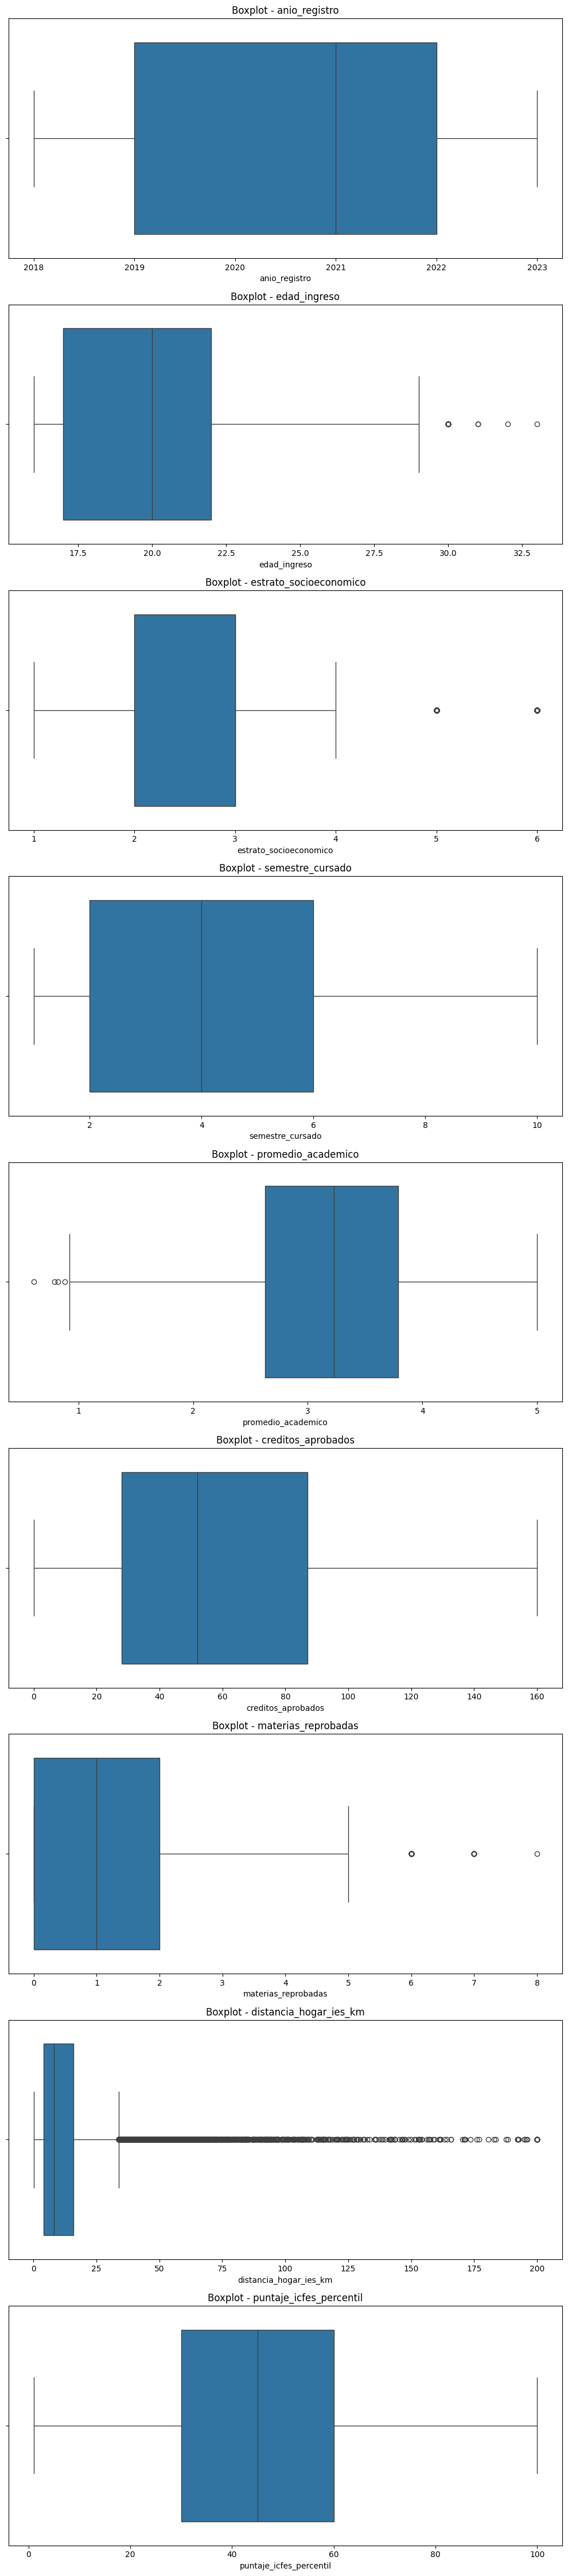

In [12]:
# 1. Identificar variables binarias (solo 0 y 1)
binarias = [col for col in df_numericas.columns if df_numericas[col].nunique() == 2]

# 2. Excluir id_estudiante y binarias
cols = df_numericas.drop(columns=['id_estudiante']).drop(columns=binarias).columns

# 3. Graficar solo boxplots de variables continuas
plt.figure(figsize=(10, 5 * len(cols)))

for i, col in enumerate(cols, 1):
    plt.subplot(len(cols), 1, i)
    sns.boxplot(x=df_numericas[col])
    plt.title(f"Boxplot - {col}")

plt.tight_layout()
plt.show()

## Grafica Bivariadas Numericas

### KDEplot - Sin Binarias

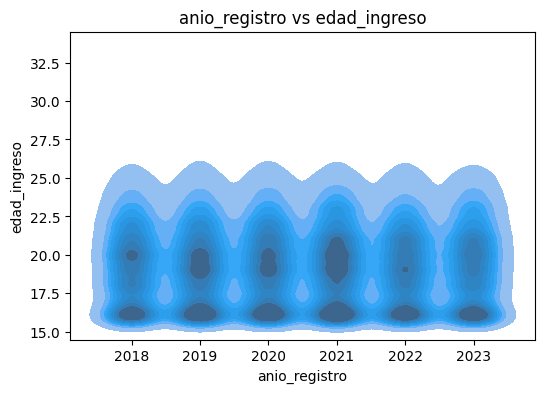

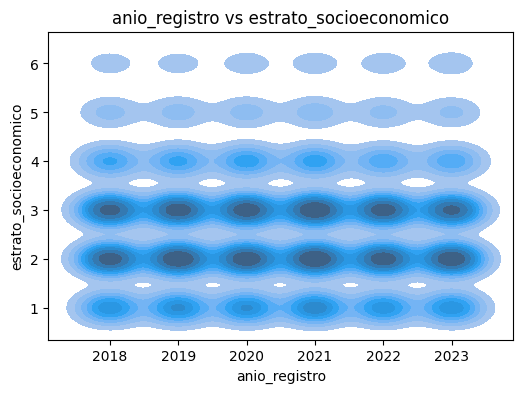

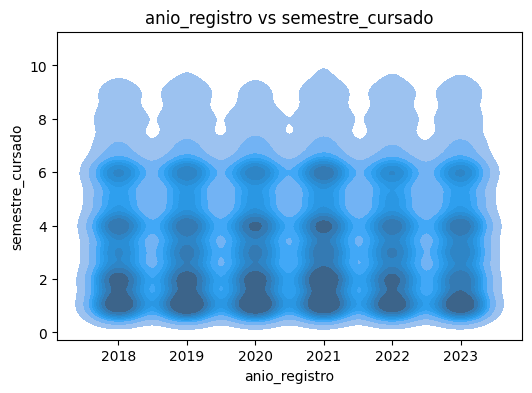

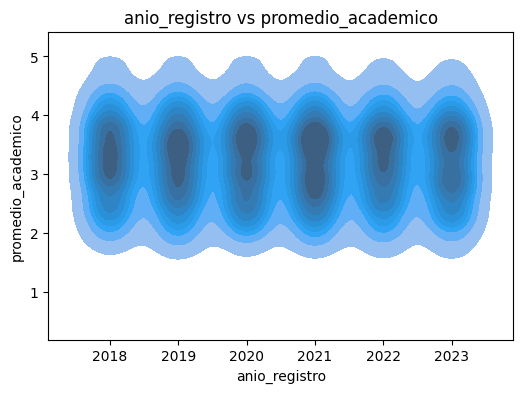

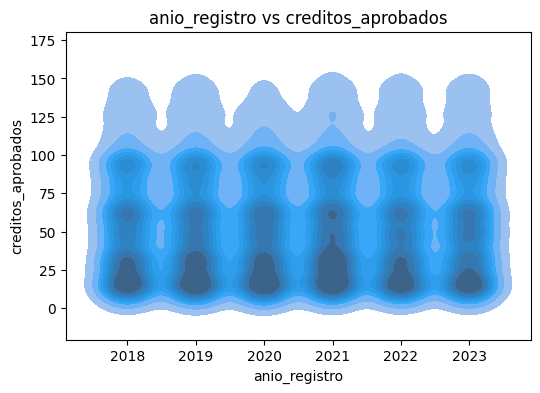

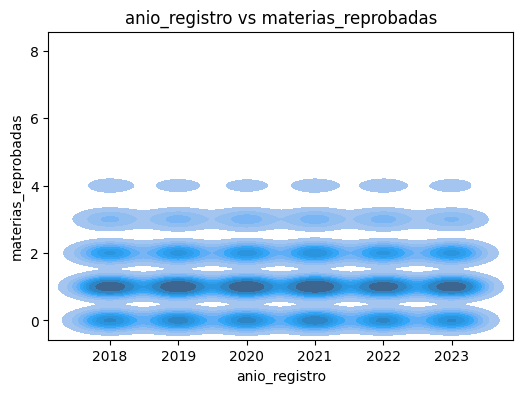

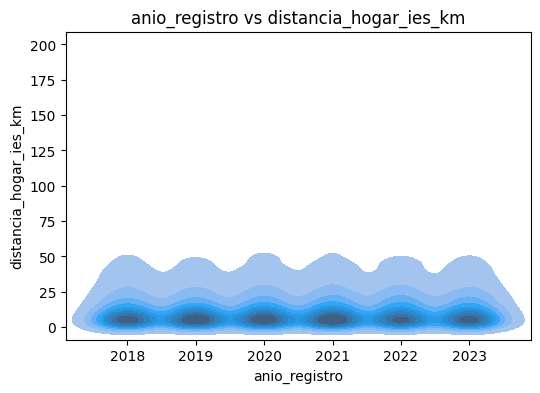

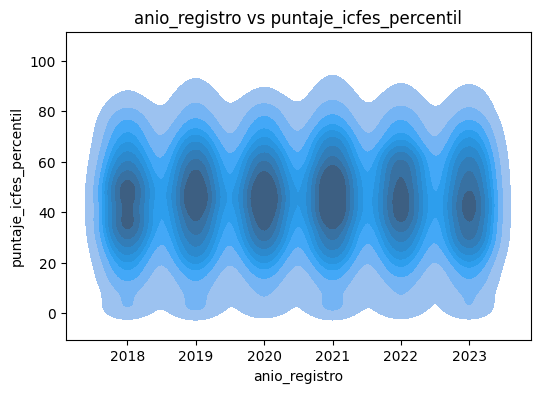

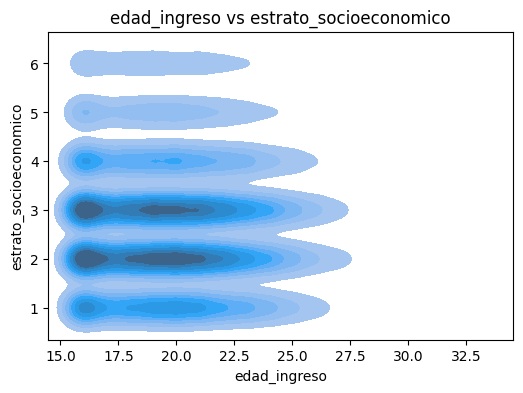

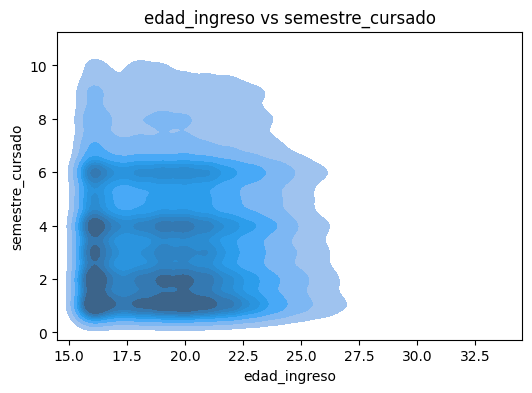

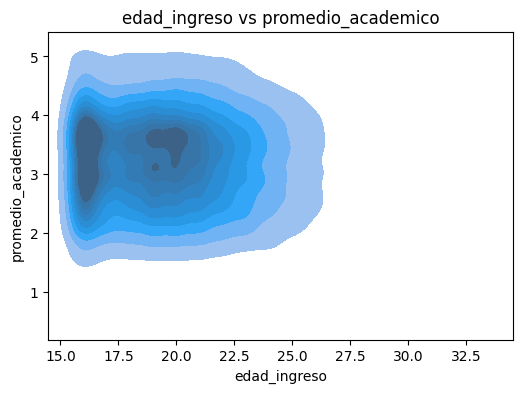

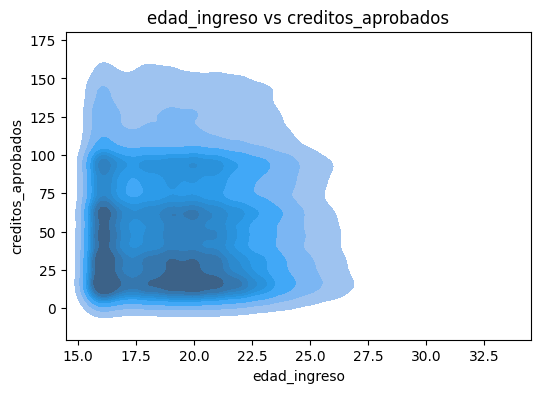

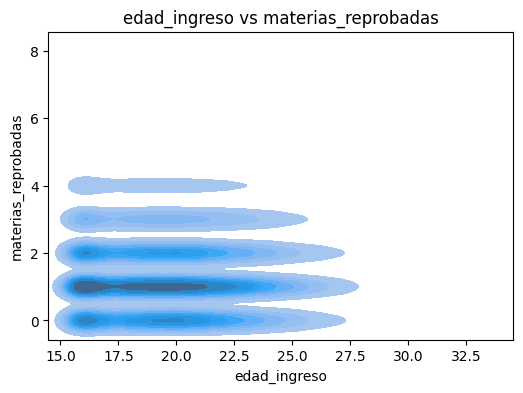

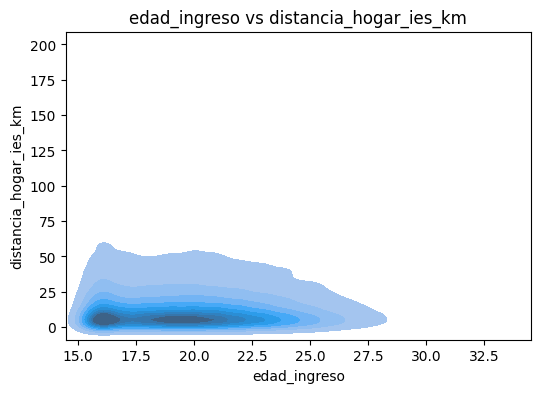

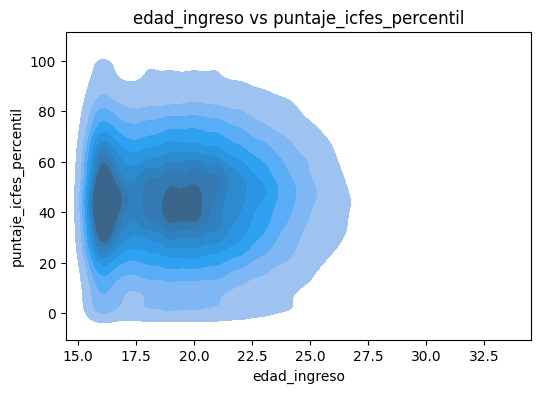

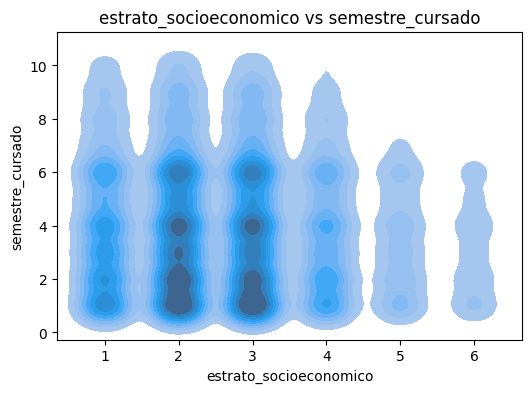

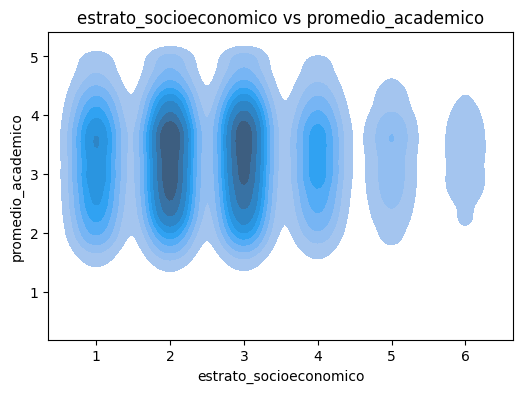

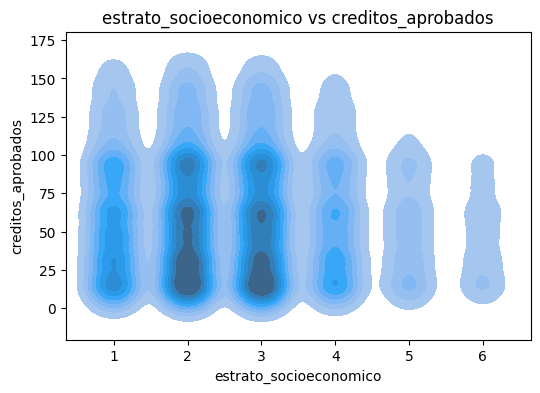

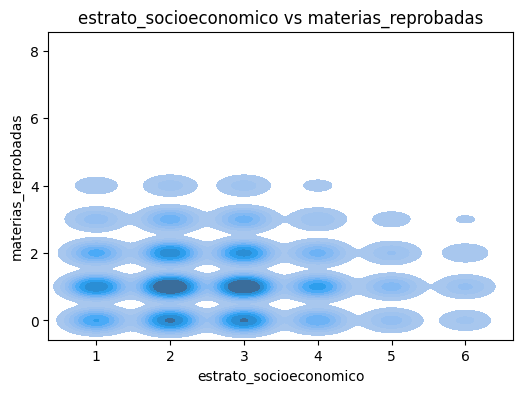

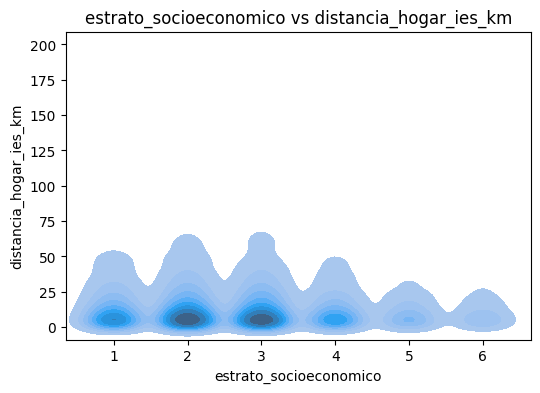

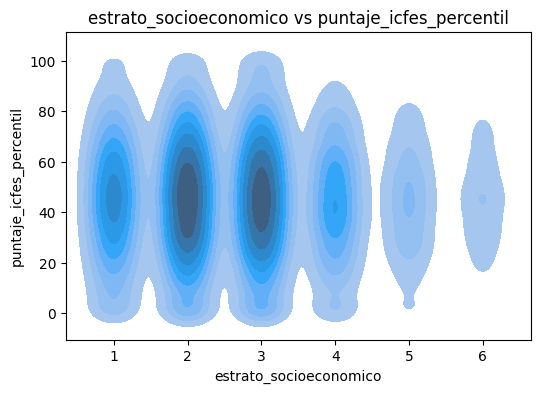

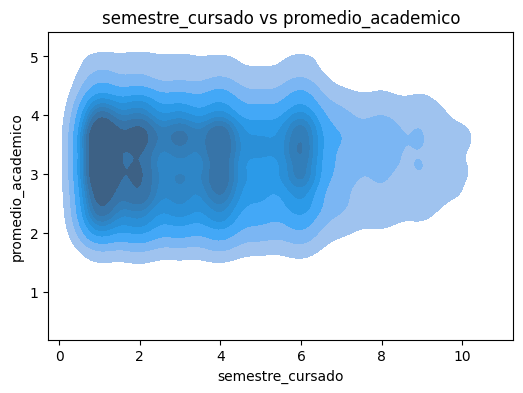

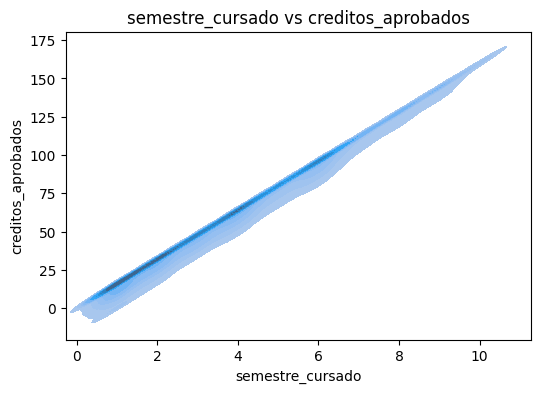

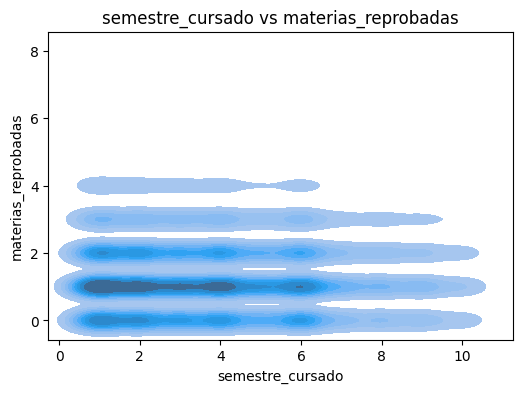

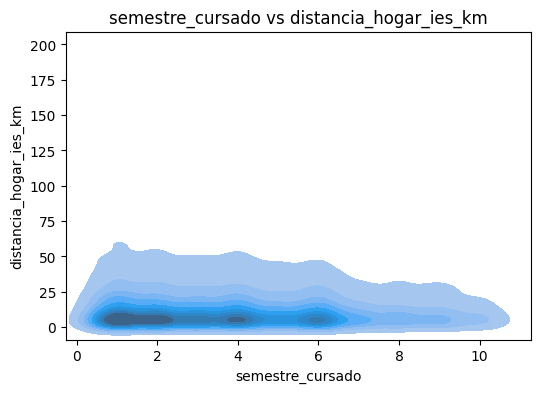

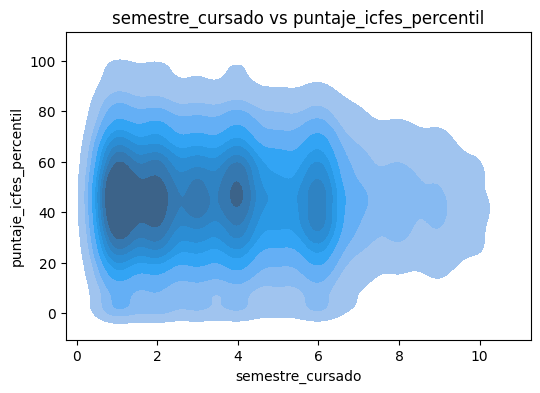

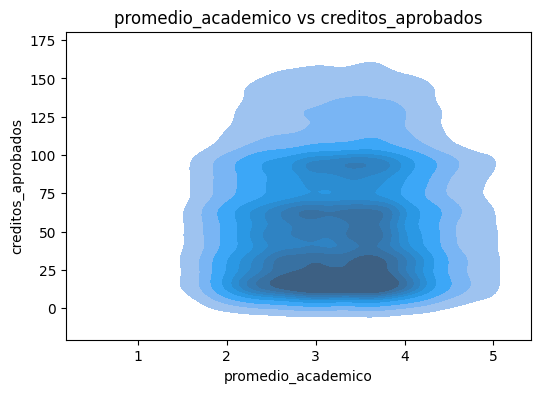

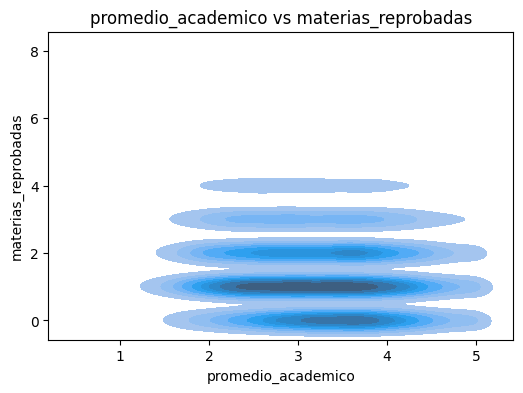

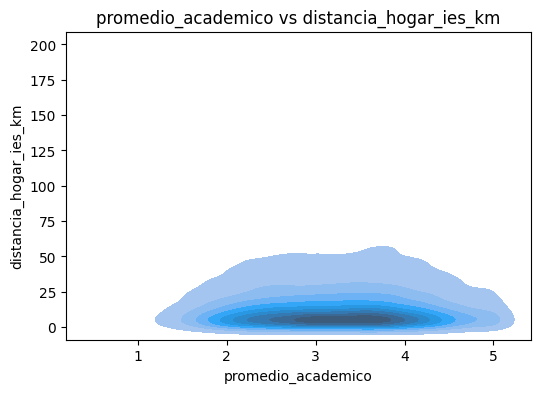

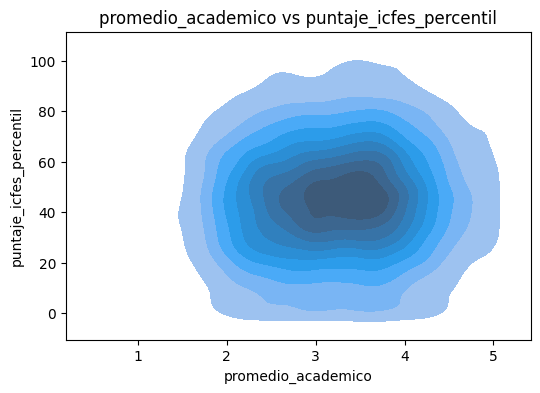

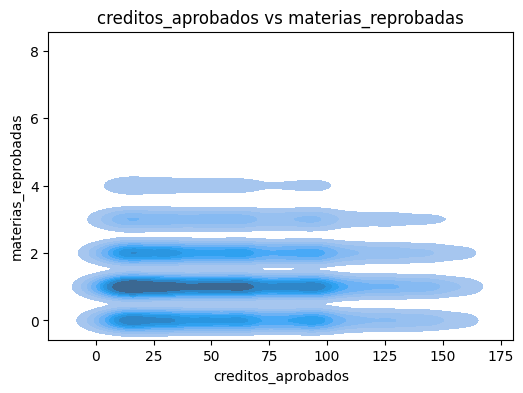

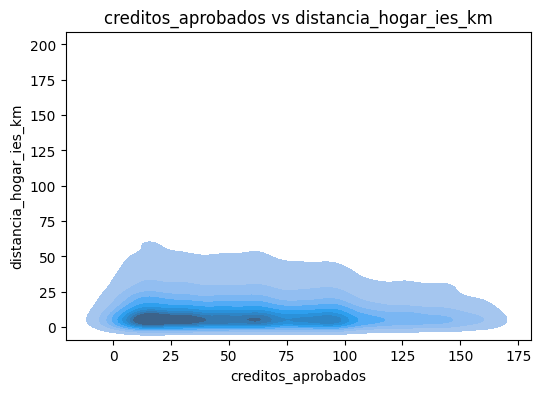

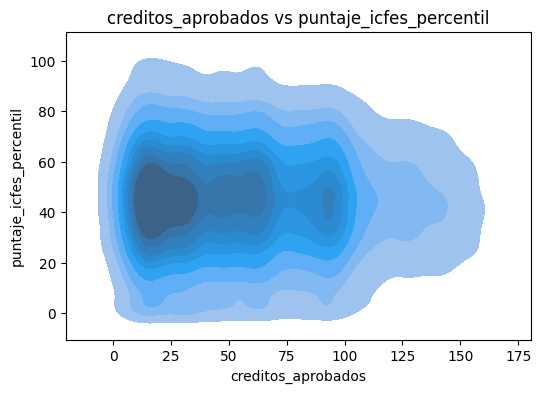

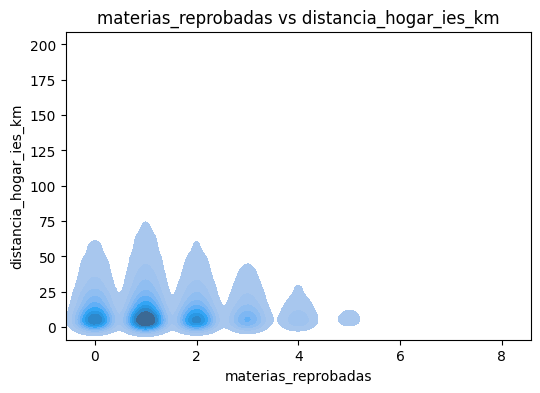

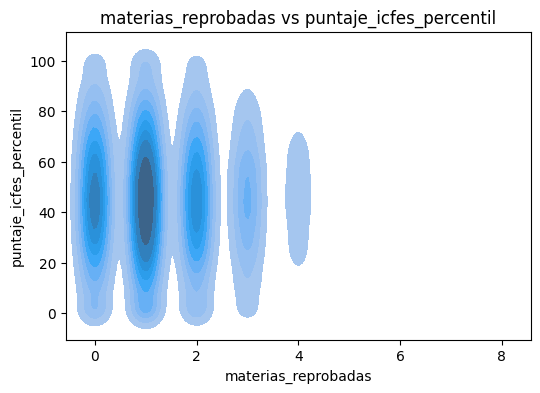

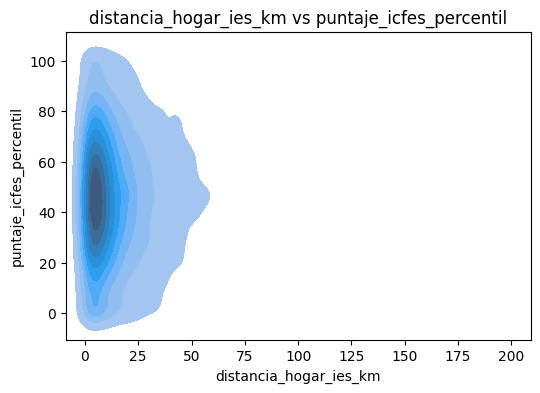

In [ ]:
# 1. Identificar binarias
binarias = [col for col in df_numericas.columns if df_numericas[col].nunique() == 2]

# 2. Filtrar columnas (sin id y sin binarias)
cols = df_numericas.drop(columns=['id_estudiante']).drop(columns=binarias).columns

# 3. Generar todas las combinaciones
pares = list(itertools.combinations(cols, 2))

# 4. Graficar TODAS
for x, y in pares:
    plt.figure(figsize=(6,4))
    sns.kdeplot(x=df[x], y=df[y], fill=True)
    plt.title(f"{x} vs {y}")
    plt.show()

### Box - Plot con Binarias

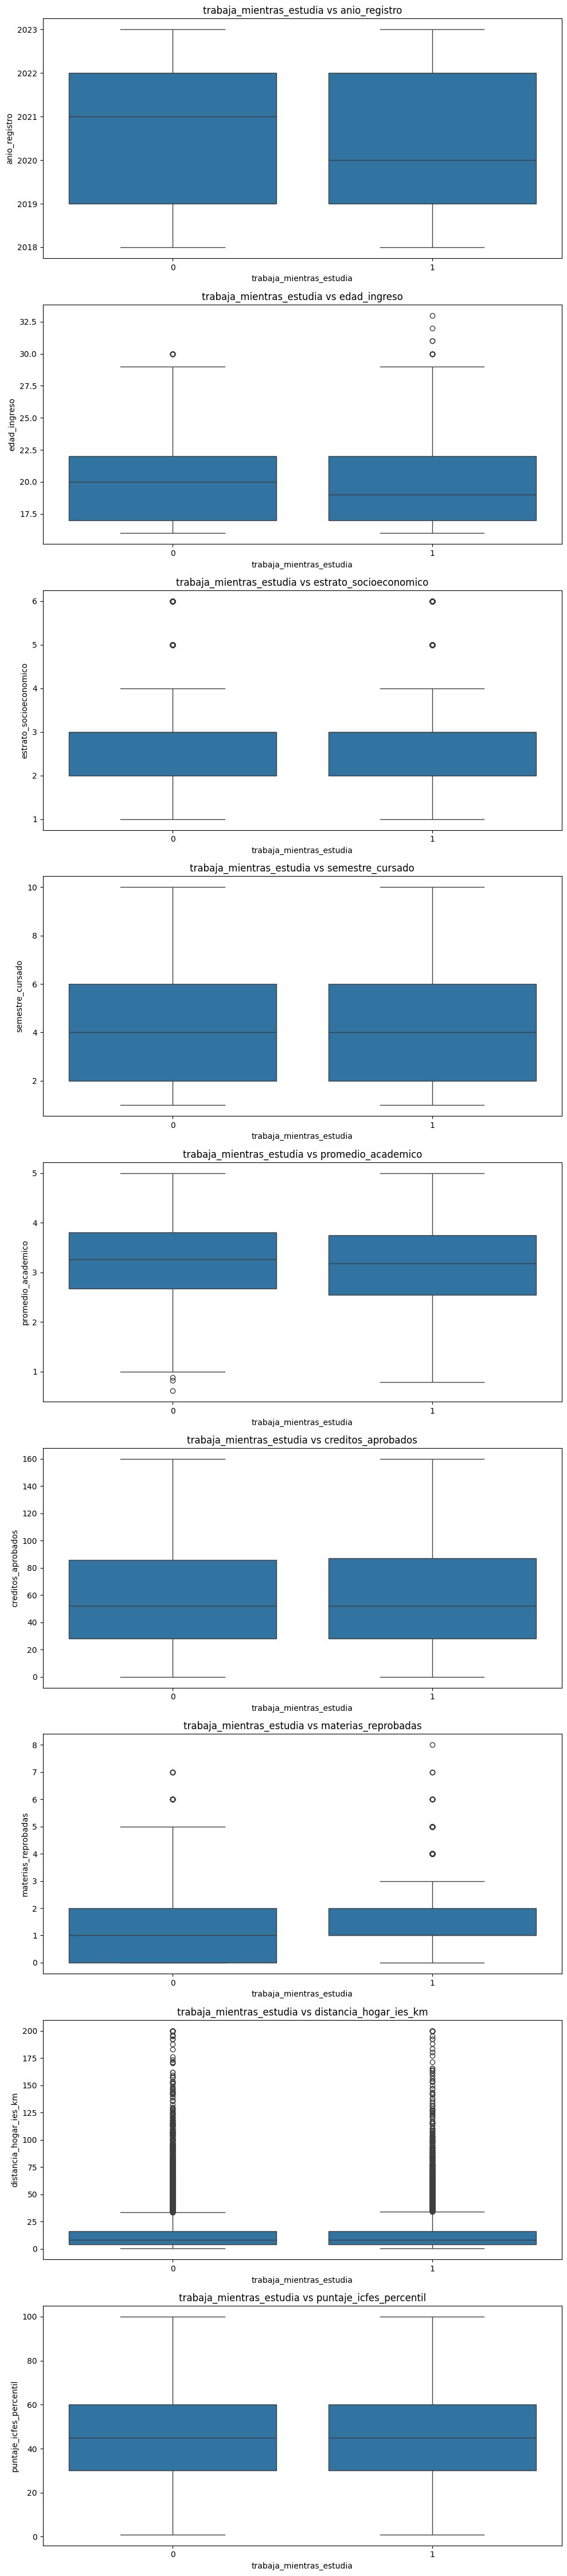

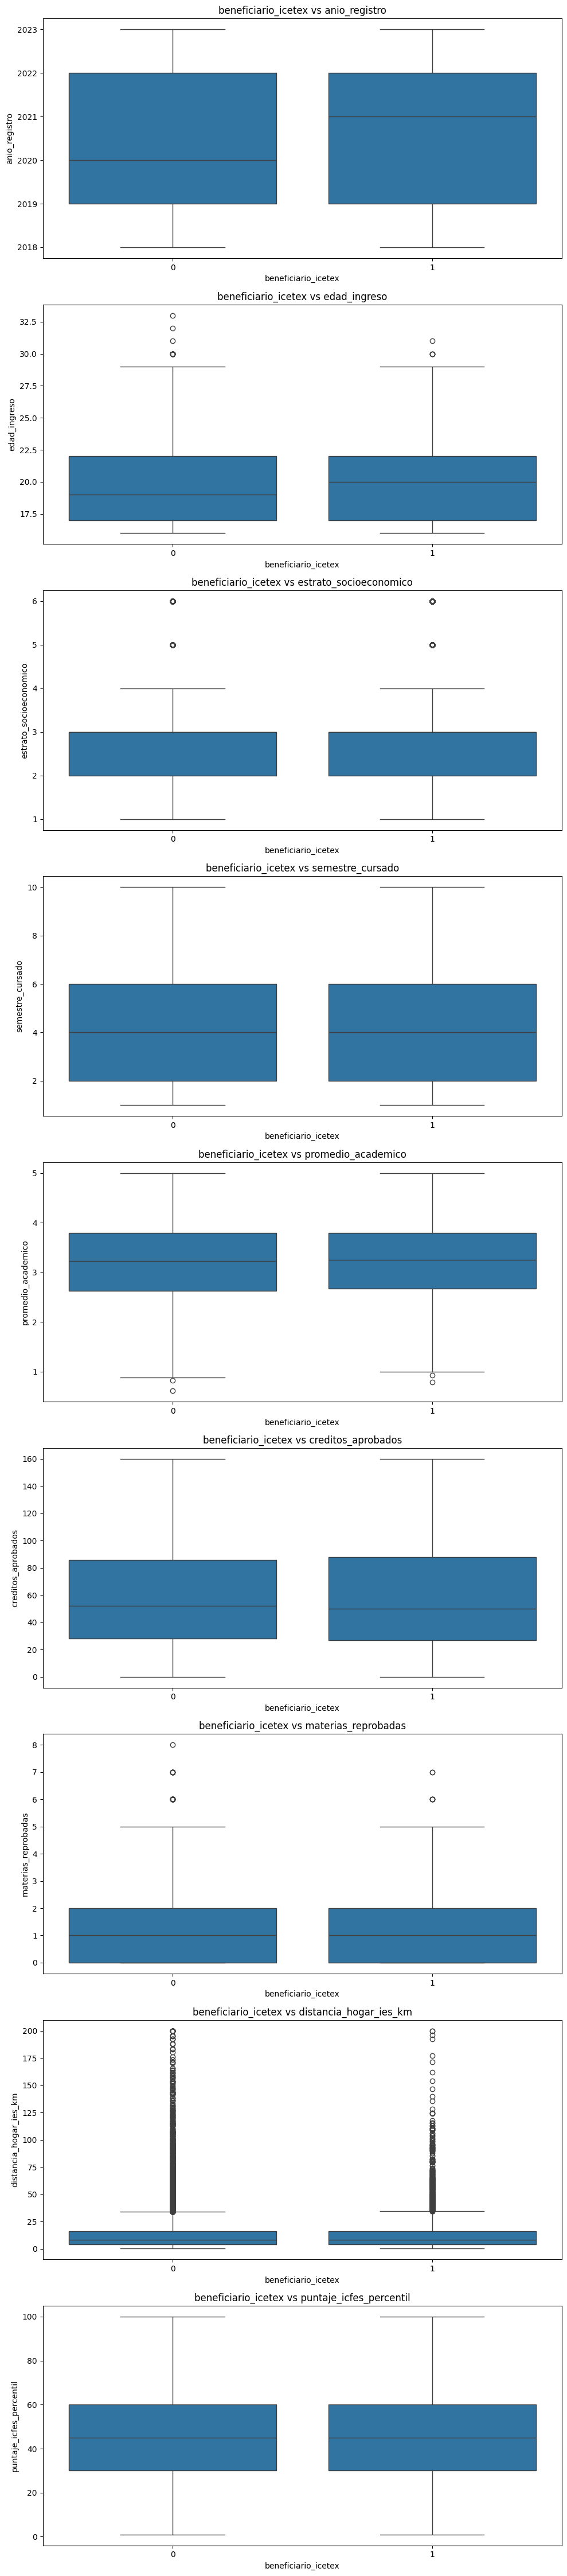

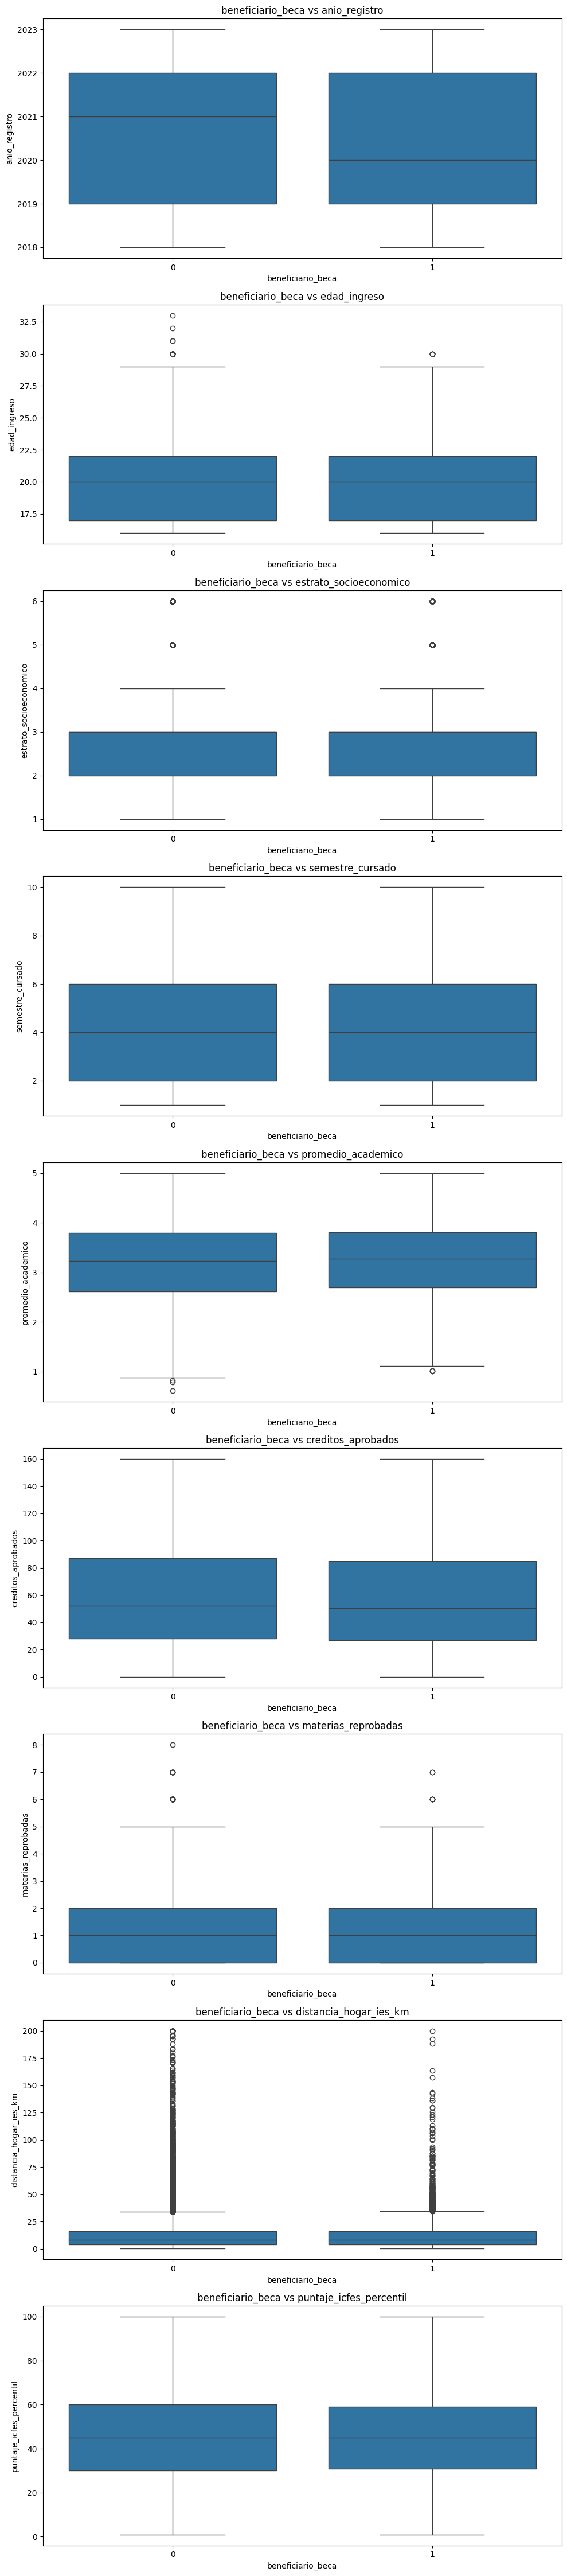

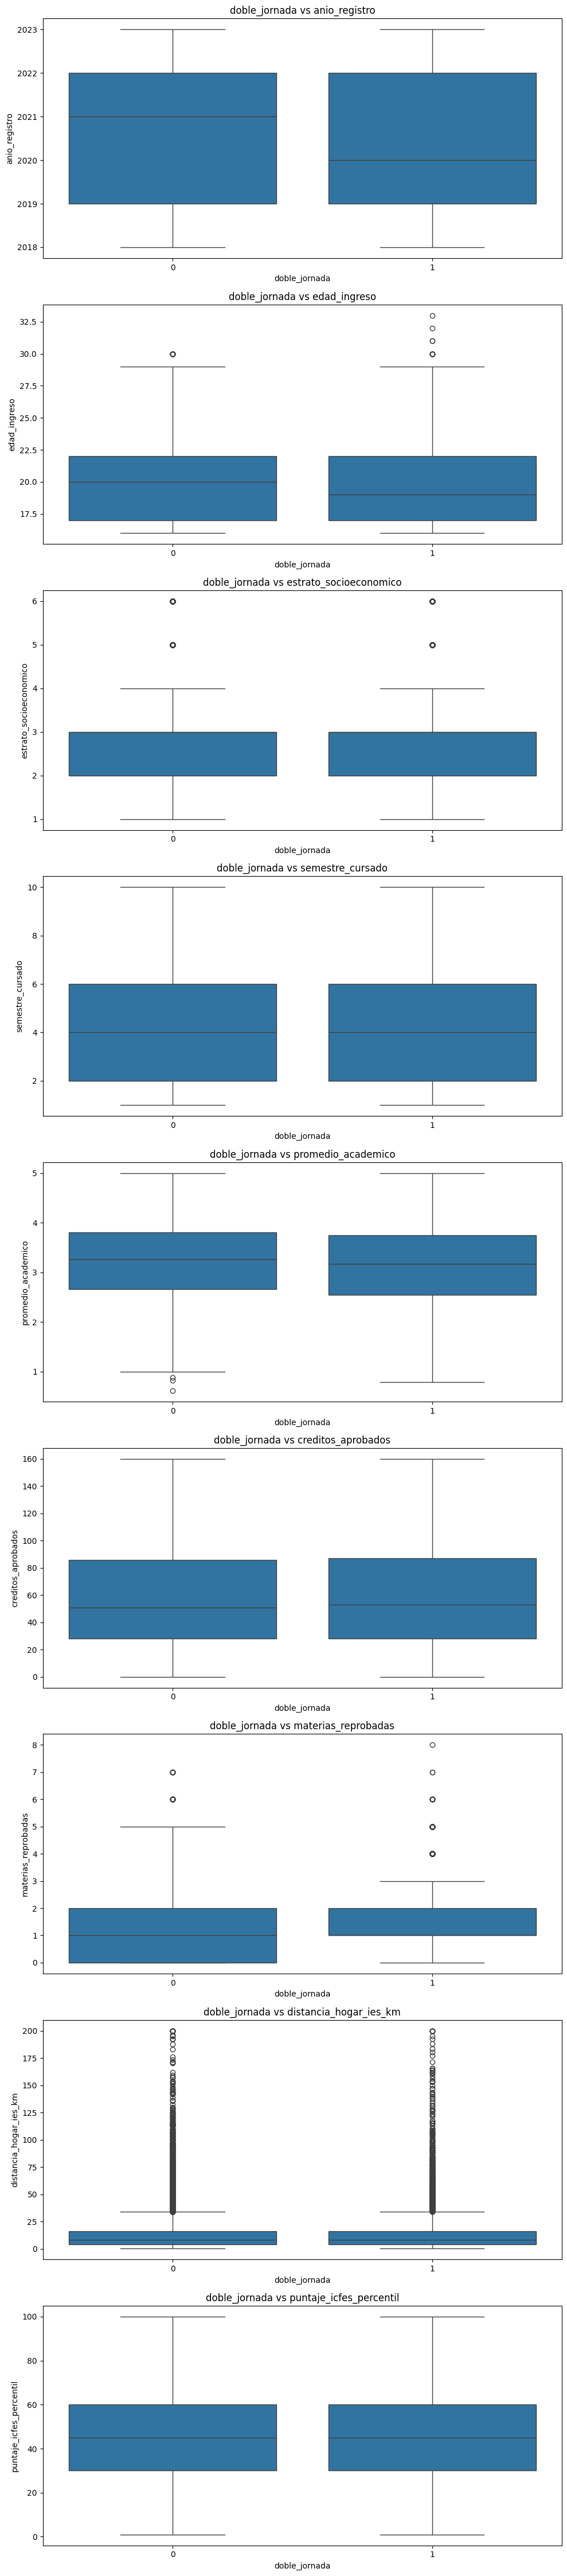

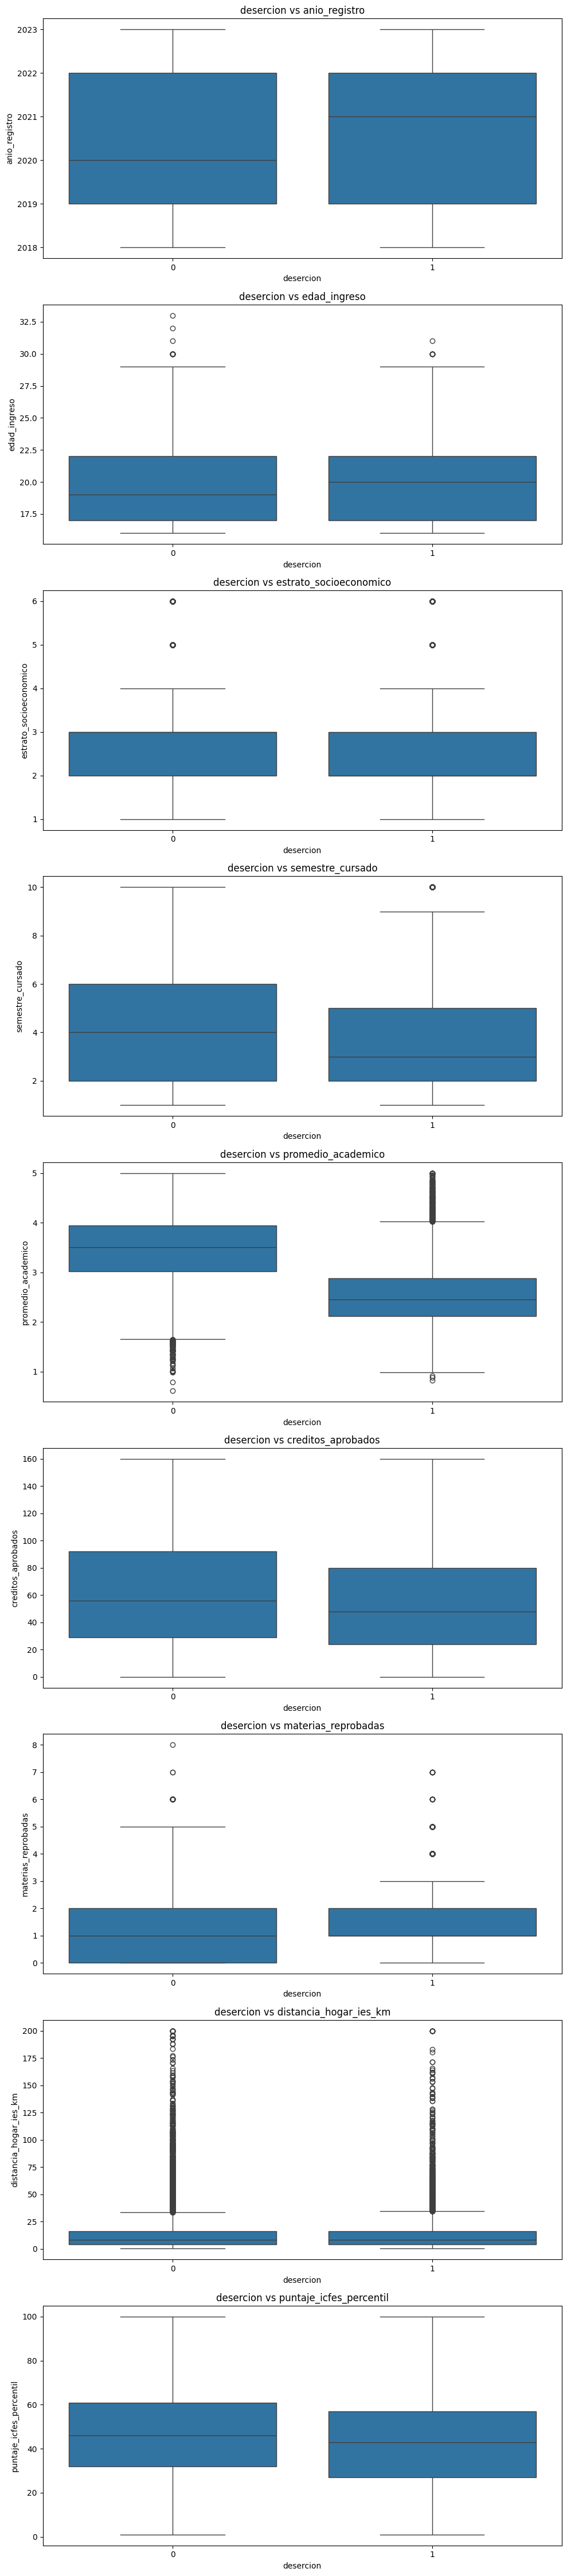

In [13]:
# 1. Identificar variables binarias (0/1)
binarias = [col for col in df_numericas.columns if df_numericas[col].nunique() == 2]

# 2. Identificar variables numéricas
numericas = df.select_dtypes(include=['int64', 'float64']).columns

# 3. Quitar variables que no sirven
numericas = numericas.drop('id_estudiante')

# 4. Quitar binarias de las numéricas
numericas = [n for n in numericas if n not in binarias]

# 5. Loop por cada binaria
for b in binarias:

    plt.figure(figsize=(10, 5 * len(numericas)))

    for i, n in enumerate(numericas, 1):
        plt.subplot(len(numericas), 1, i)
        sns.boxplot(x=df[b], y=df[n])
        plt.title(f"{b} vs {n}")

    plt.tight_layout()
    plt.show()

### Binarias vs Desercion

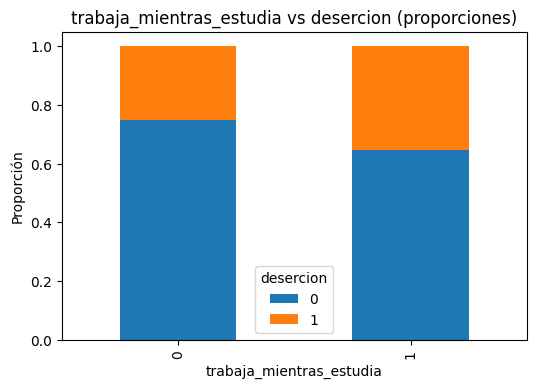


--- trabaja_mientras_estudia ---
desercion                        0         1
trabaja_mientras_estudia                    
0                         0.749119  0.250881
1                         0.646378  0.353622


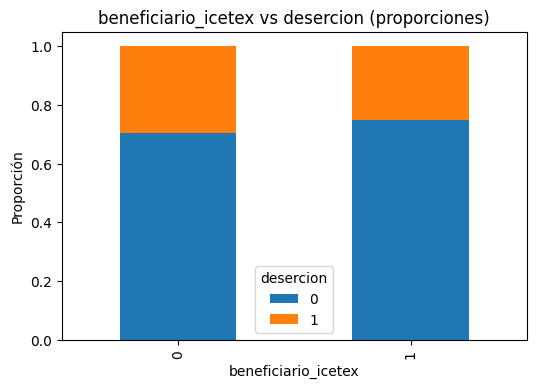


--- beneficiario_icetex ---
desercion                   0         1
beneficiario_icetex                    
0                    0.704964  0.295036
1                    0.748856  0.251144


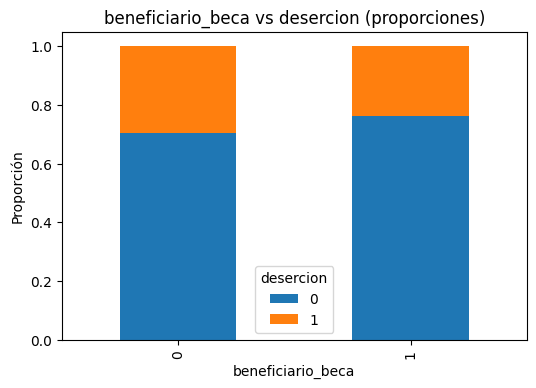


--- beneficiario_beca ---
desercion                 0         1
beneficiario_beca                    
0                  0.705893  0.294107
1                  0.763992  0.236008


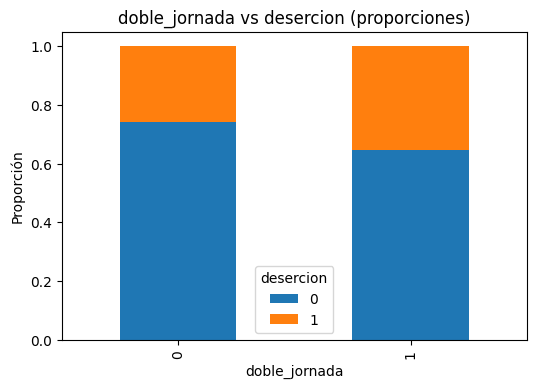


--- doble_jornada ---
desercion             0         1
doble_jornada                    
0              0.743699  0.256301
1              0.645817  0.354183


In [14]:
# 1. Seleccionar variables numéricas
numericas = df.select_dtypes(include=['int64', 'float64']).columns

# 2. Identificar variables binarias reales (solo 0 y 1)
binarias = [
    col for col in numericas
    if df[col].dropna().isin([0,1]).all() and col != 'desercion'
]

# 3. GRÁFICOS (proporciones, más claros que countplot)
for col in binarias:

    # Tabla de proporciones
    tabla = pd.crosstab(df[col], df['desercion'], normalize='index')

    # Gráfico
    tabla.plot(kind='bar', stacked=True, figsize=(6,4))
    plt.title(f"{col} vs desercion (proporciones)")
    plt.ylabel("Proporción")
    plt.xlabel(col)
    plt.legend(title='desercion')
    plt.show()

    # Imprimir tabla
    print(f"\n--- {col} ---")
    print(tabla)

### Heatmap Numericas

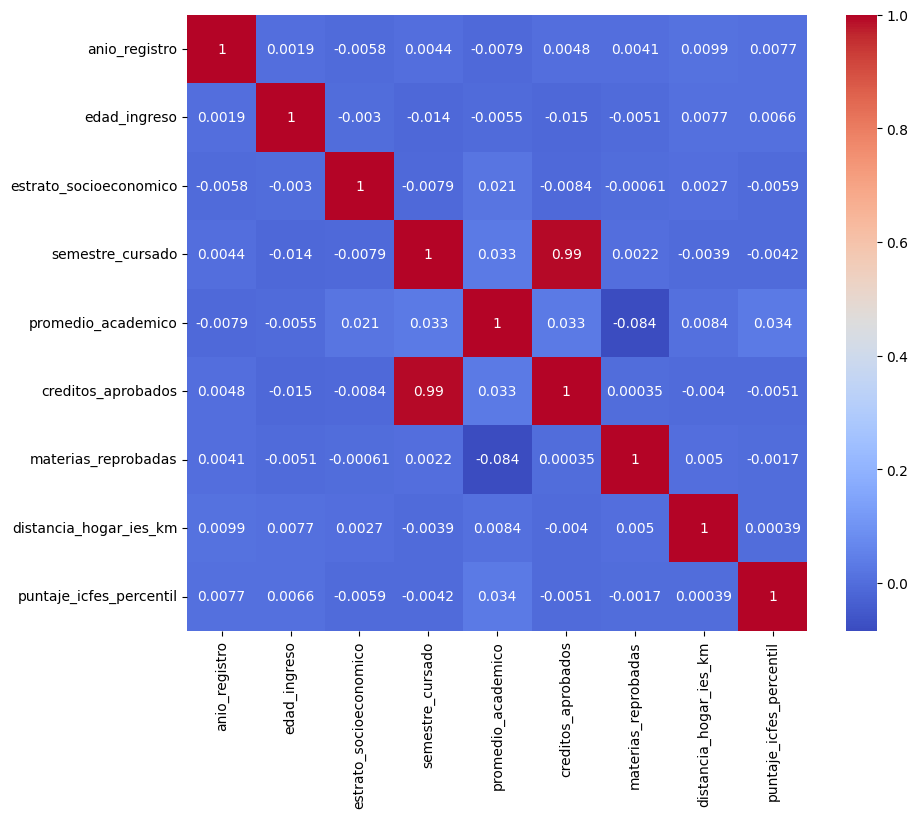

In [15]:
numericas_continuas = [
    col for col in df.select_dtypes(include=['int64','float64']).columns
    if df[col].nunique() > 2 and col != 'id_estudiante'
]

plt.figure(figsize=(10,8))
sns.heatmap(df[numericas_continuas].corr(), annot=True, cmap='coolwarm')
plt.show()

In [16]:
corr_matrix = df[numericas_continuas].corr().abs()

# Triángulo superior
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Columnas a eliminar
to_drop = [col for col in upper.columns if any(upper[col] > 0.8)]

print("Columnas a eliminar:", to_drop)

Columnas a eliminar: ['creditos_aprobados']


In [17]:
df = df.drop(columns=to_drop)

In [18]:
# Variables numéricas (incluye binarias)
numericas = df.select_dtypes(include=['int64','float64']).columns

# Quitar id
numericas = numericas.drop('id_estudiante')

# Correlación con desercion
corr_target = df[numericas].corr()['desercion'].sort_values(ascending=False)

print(corr_target)

desercion                   1.000000
materias_reprobadas         0.195141
trabaja_mientras_estudia    0.108518
doble_jornada               0.100499
anio_registro               0.013498
edad_ingreso                0.008088
distancia_hogar_ies_km      0.006865
beneficiario_icetex        -0.037272
beneficiario_beca          -0.041730
estrato_socioeconomico     -0.054461
puntaje_icfes_percentil    -0.073591
semestre_cursado           -0.080178
promedio_academico         -0.535692
Name: desercion, dtype: float64


### Tabla Cruzada Binarias

In [19]:
binarias = [
    col for col in df.columns
    if df[col].dropna().isin([0,1]).all() and col != 'desercion'
]

for i in range(len(binarias)):
    for j in range(i+1, len(binarias)):
        b1, b2 = binarias[i], binarias[j]

        tabla = pd.crosstab(df[b1], df[b2], normalize='index')

        print(f"\n{b1} vs {b2}")
        print(tabla)


trabaja_mientras_estudia vs beneficiario_icetex
beneficiario_icetex              0         1
trabaja_mientras_estudia                    
0                         0.819561  0.180439
1                         0.820810  0.179190

trabaja_mientras_estudia vs beneficiario_beca
beneficiario_beca                0         1
trabaja_mientras_estudia                    
0                         0.883836  0.116164
1                         0.872969  0.127031

trabaja_mientras_estudia vs doble_jornada
doble_jornada                    0         1
trabaja_mientras_estudia                    
0                         0.948943  0.051057
1                         0.200916  0.799084

beneficiario_icetex vs beneficiario_beca
beneficiario_beca          0        1
beneficiario_icetex                  
0                    0.85366  0.14634
1                    1.00000  0.00000

beneficiario_icetex vs doble_jornada
doble_jornada               0         1
beneficiario_icetex                    
0        

In [20]:
df = df.drop(columns=['doble_jornada'])

## Histogramas Univariados Categoricas

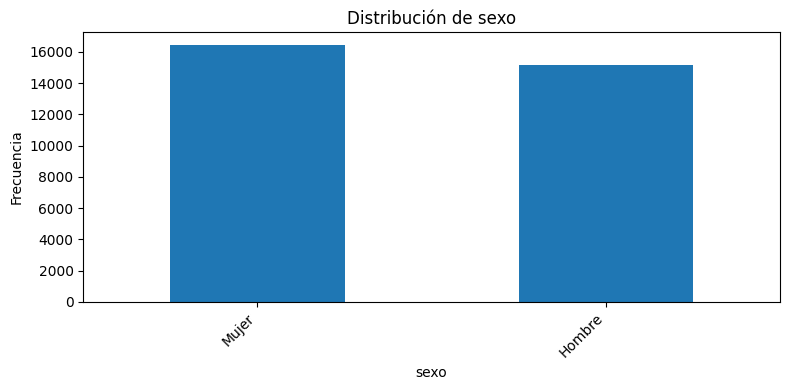

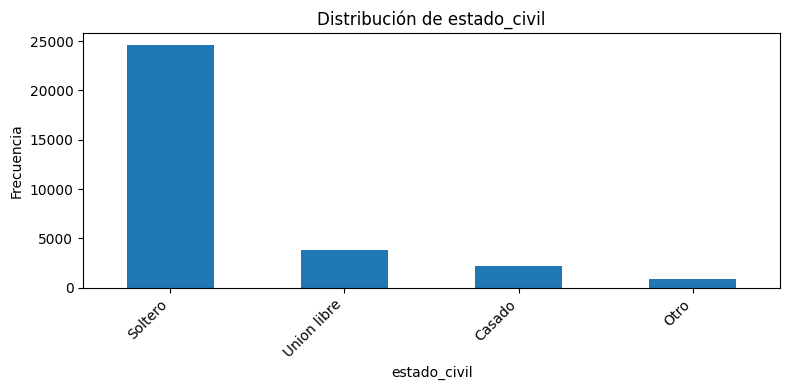

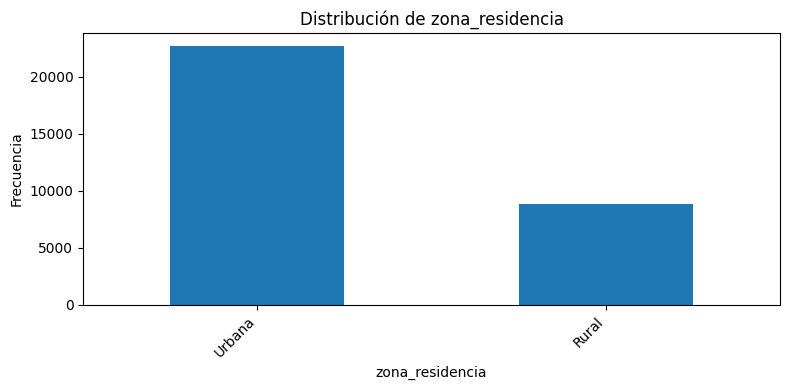

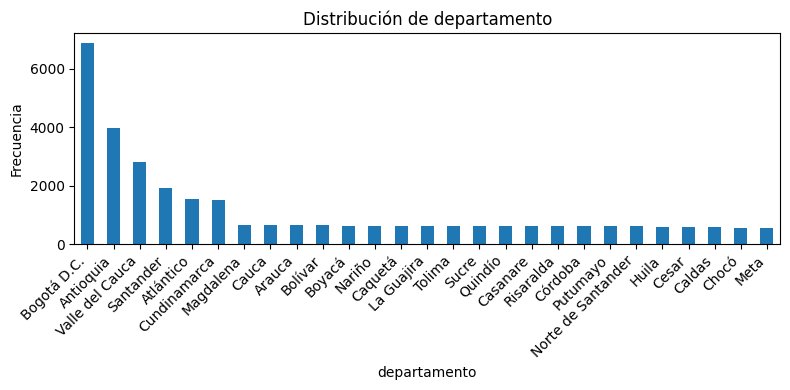

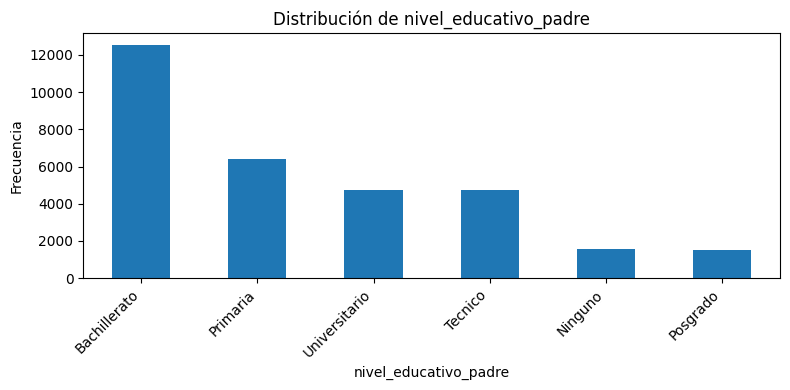

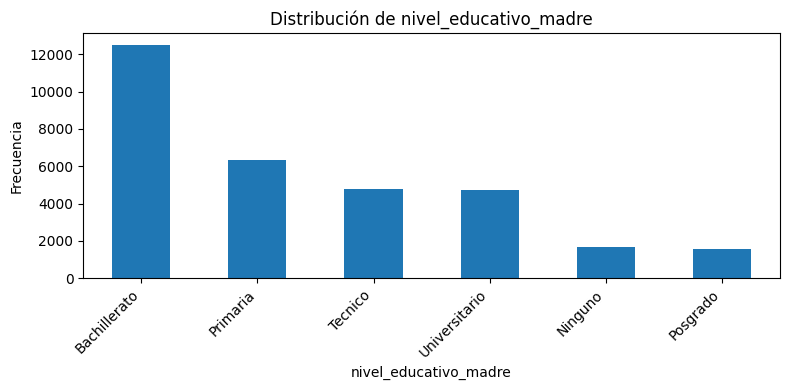

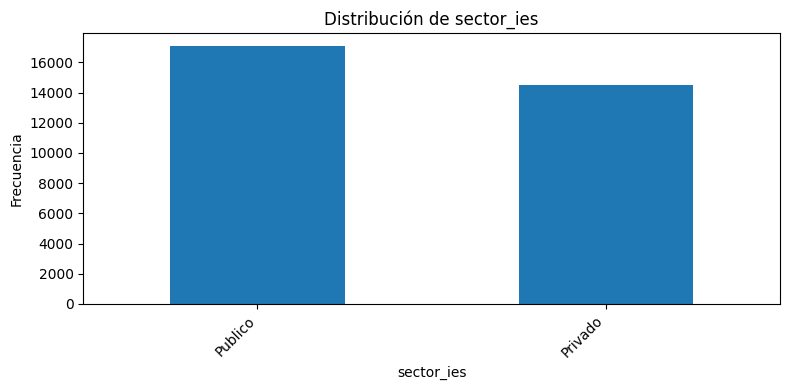

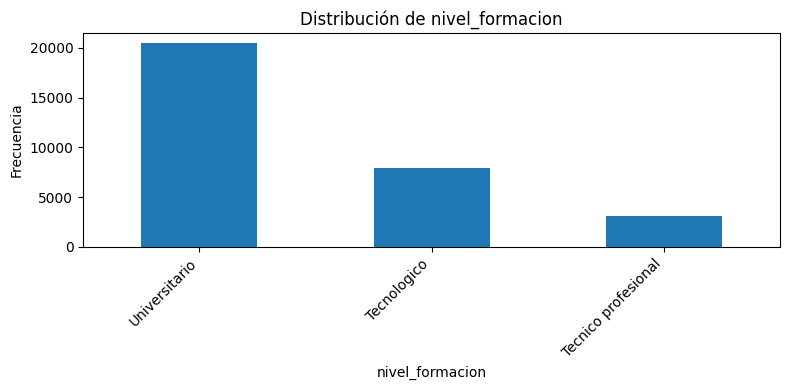

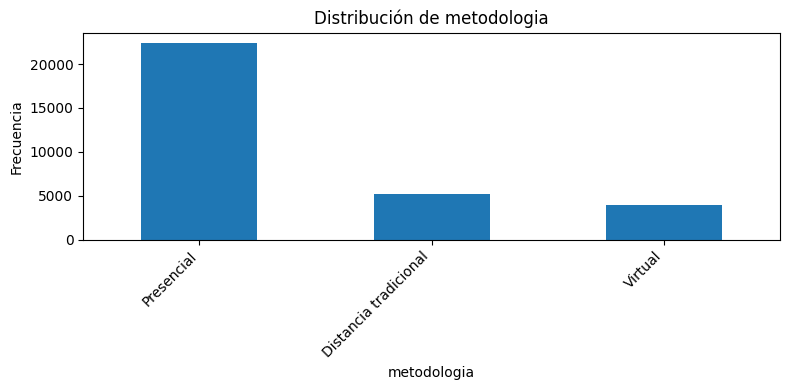

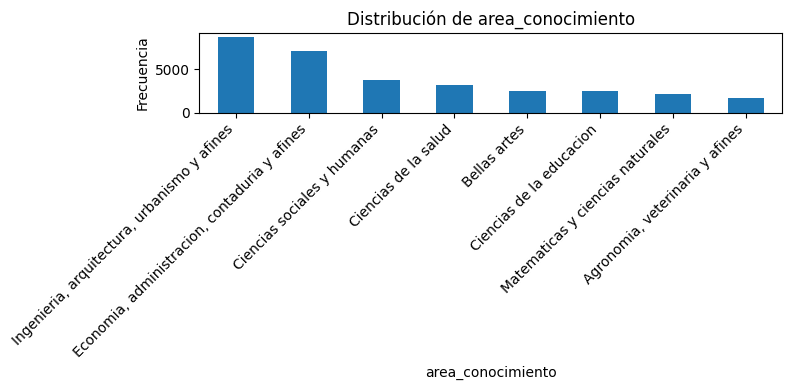

In [21]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

for col in cat_cols:
    plt.figure(figsize=(8,4))

    df[col].value_counts().plot(kind='bar')

    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

## Histogramas Bivariados Categoricas

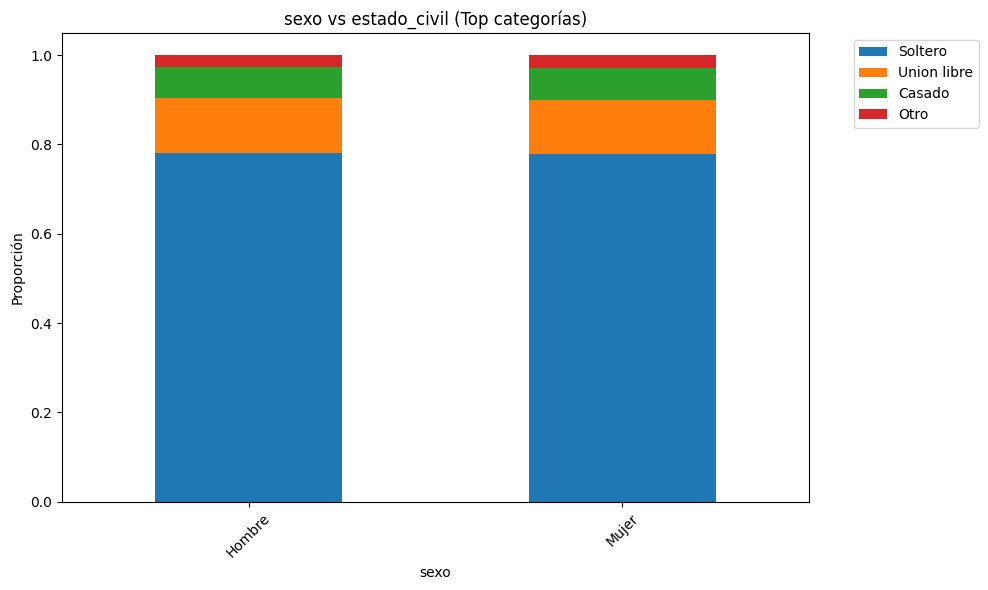

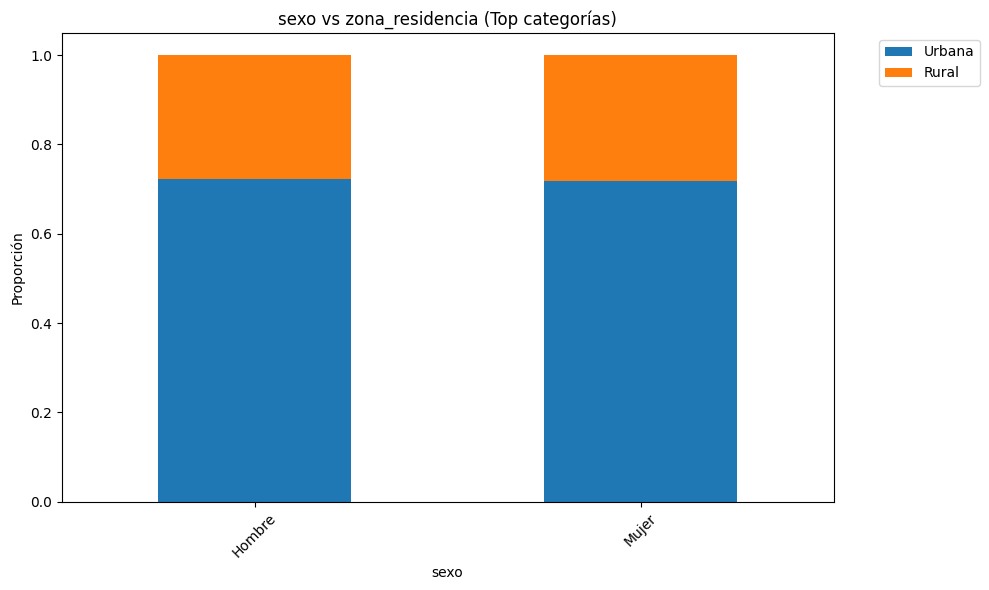

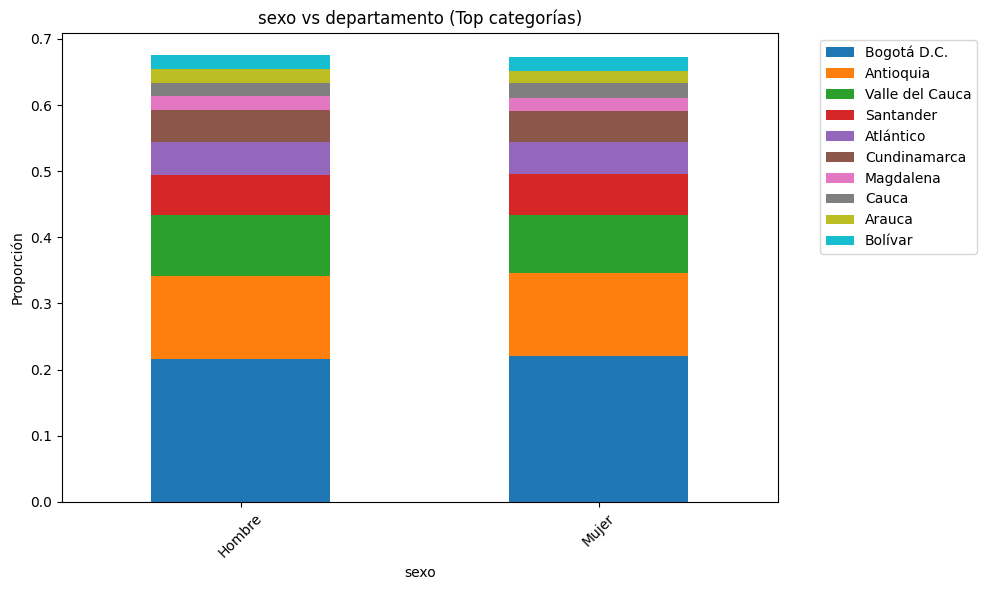

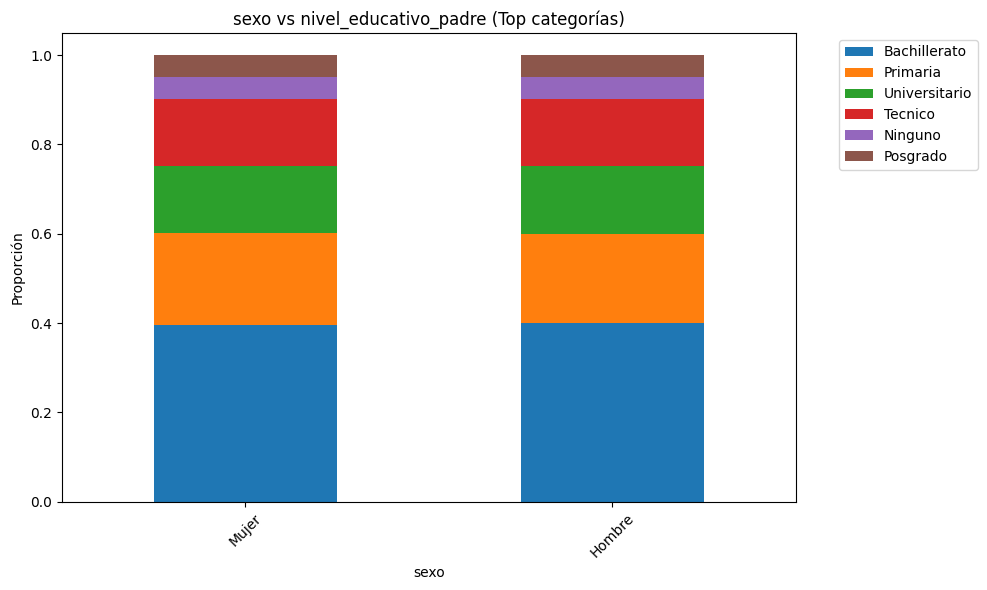

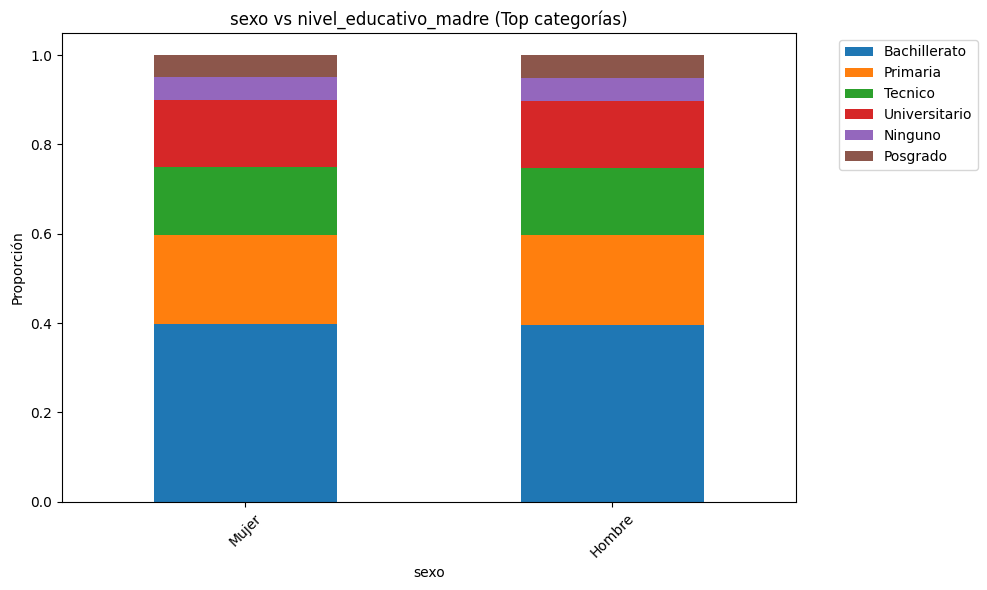

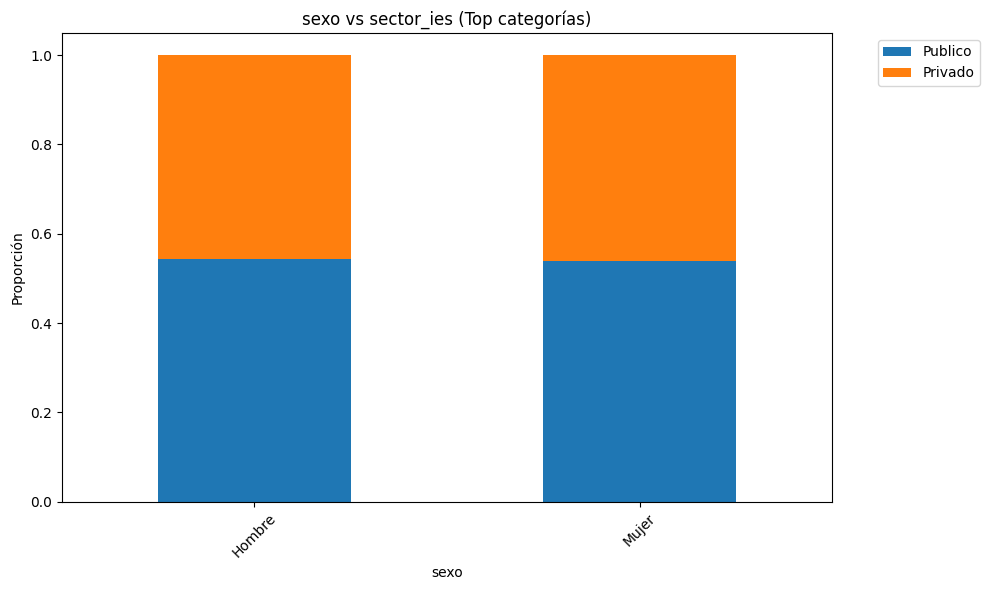

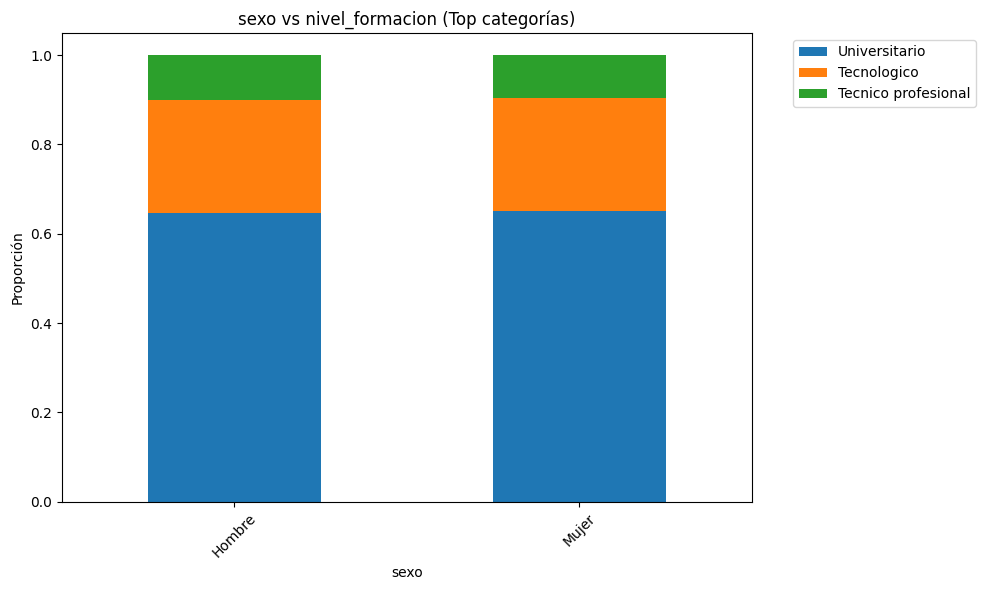

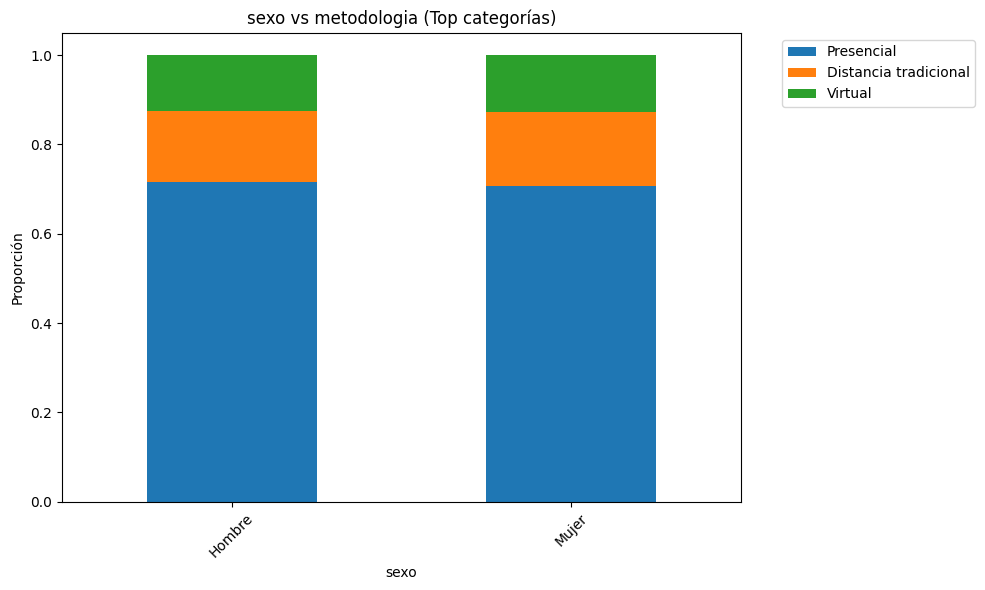

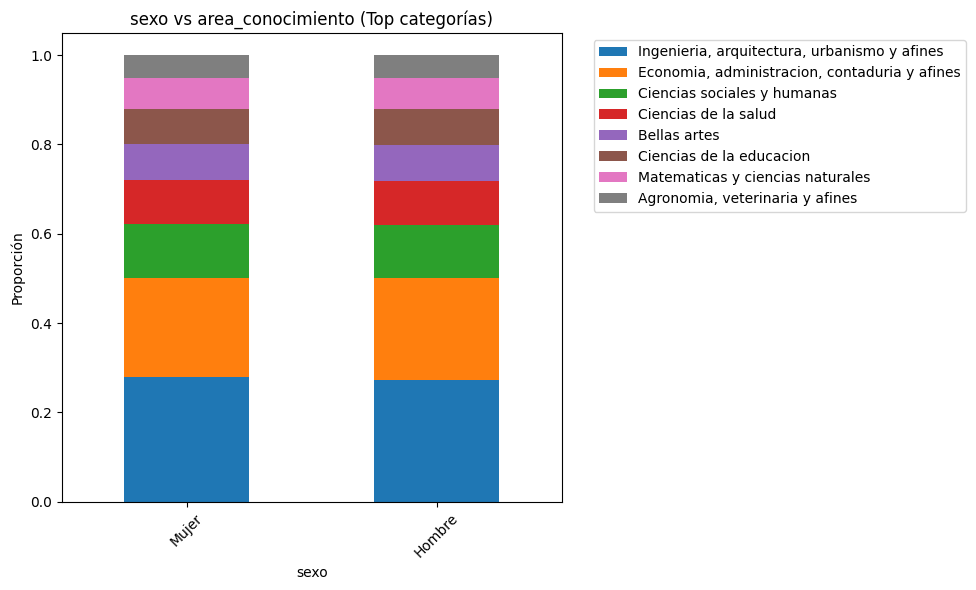

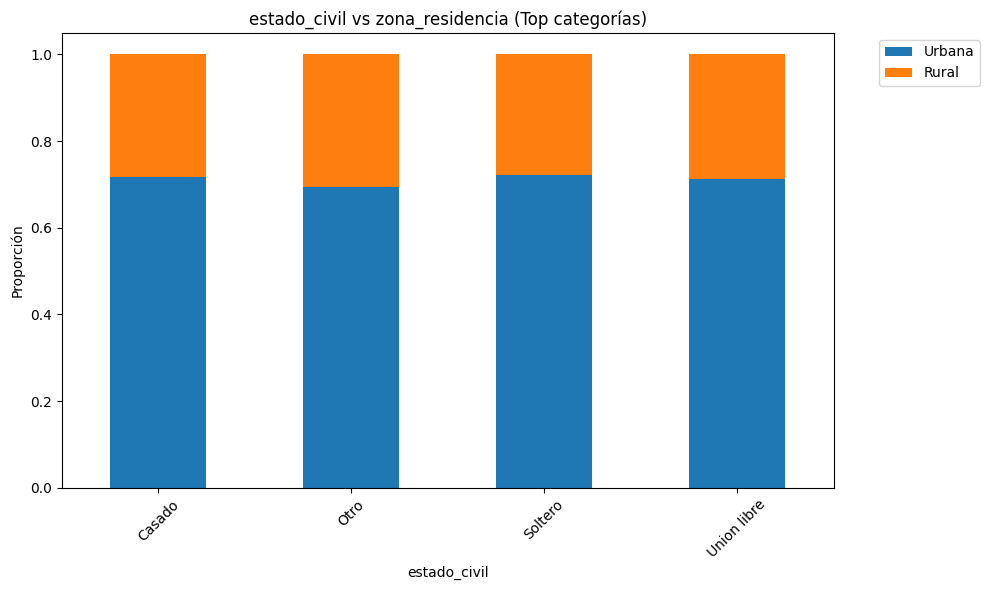

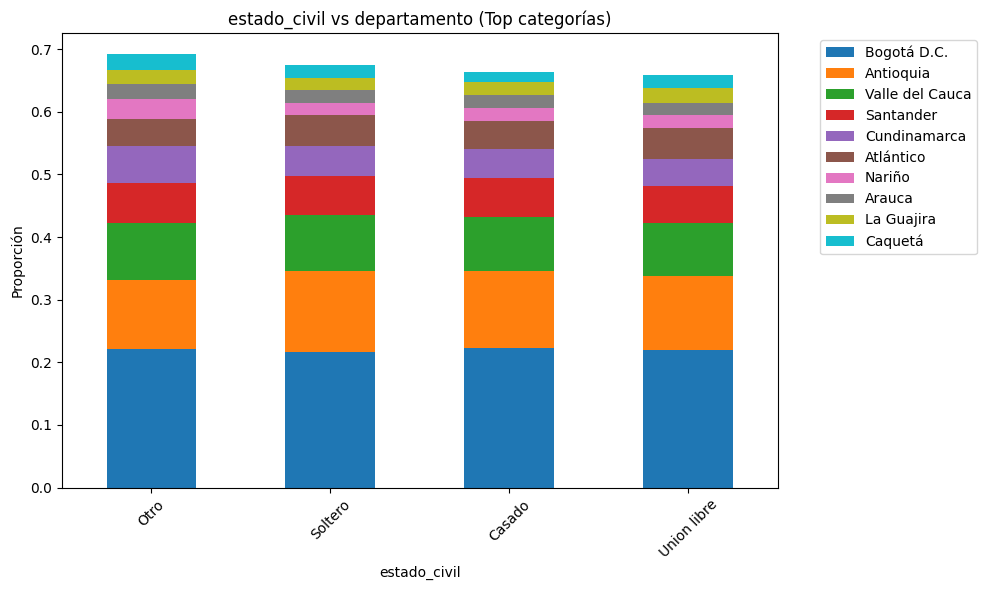

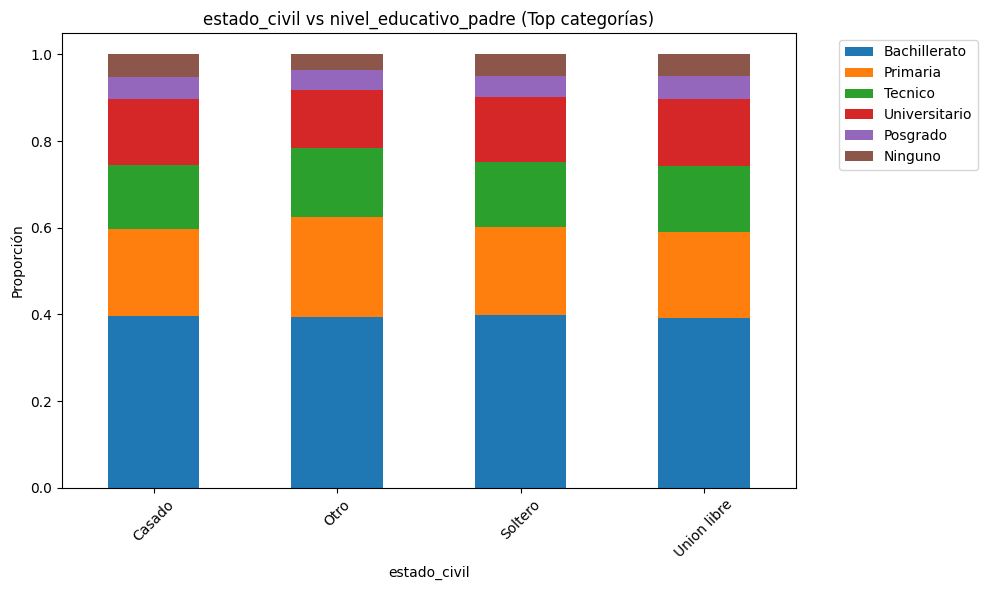

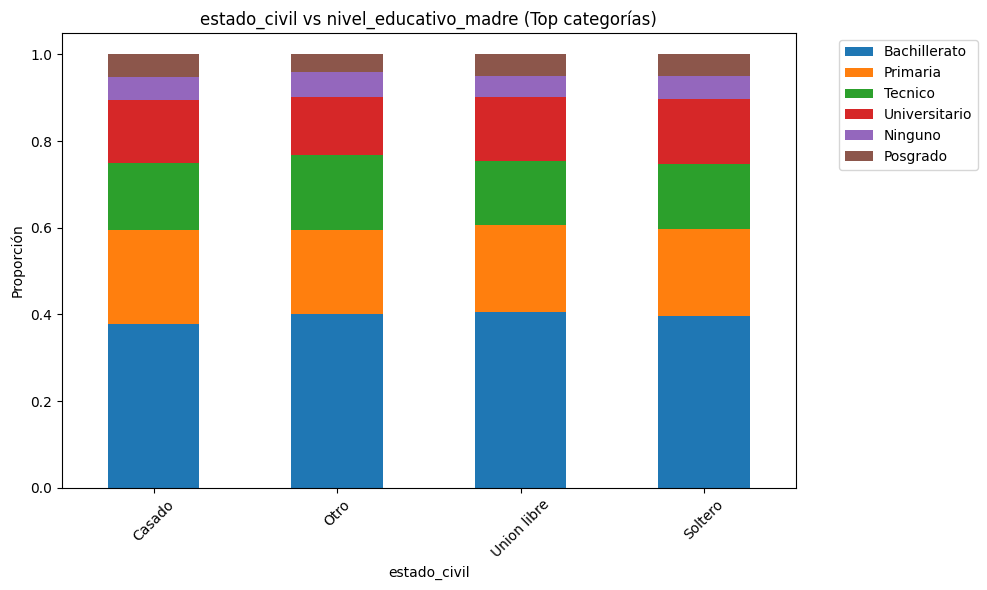

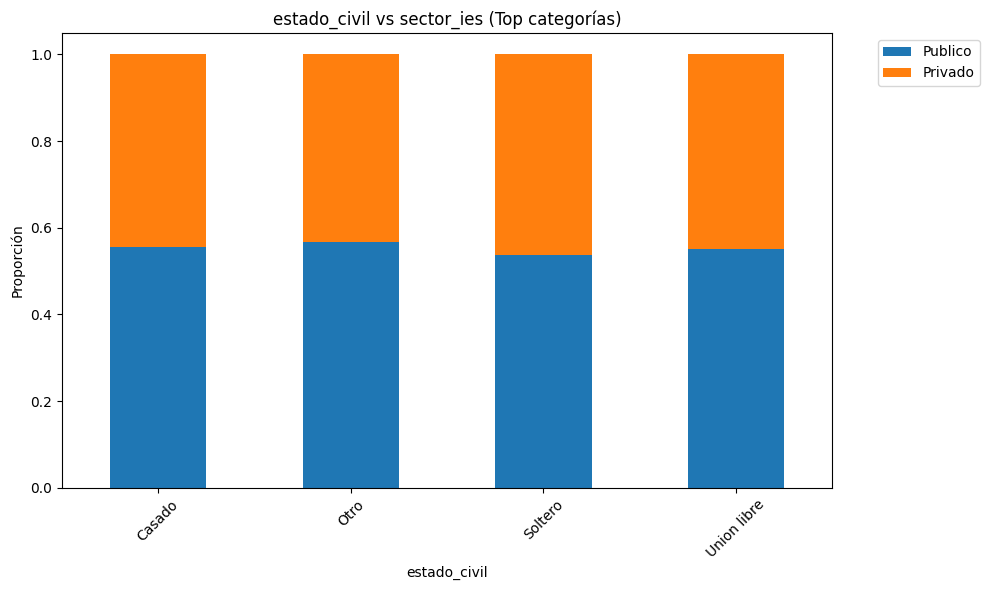

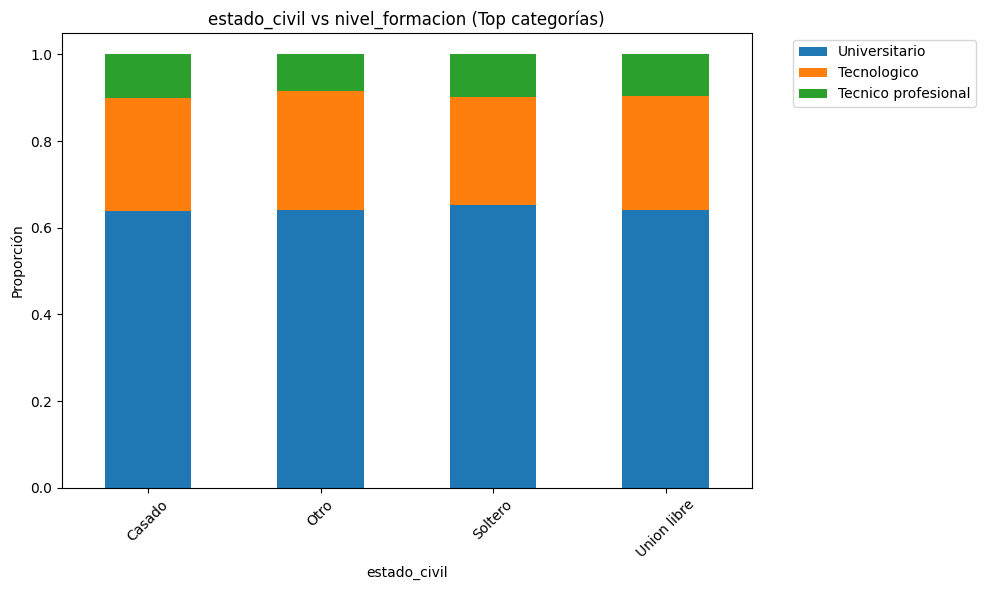

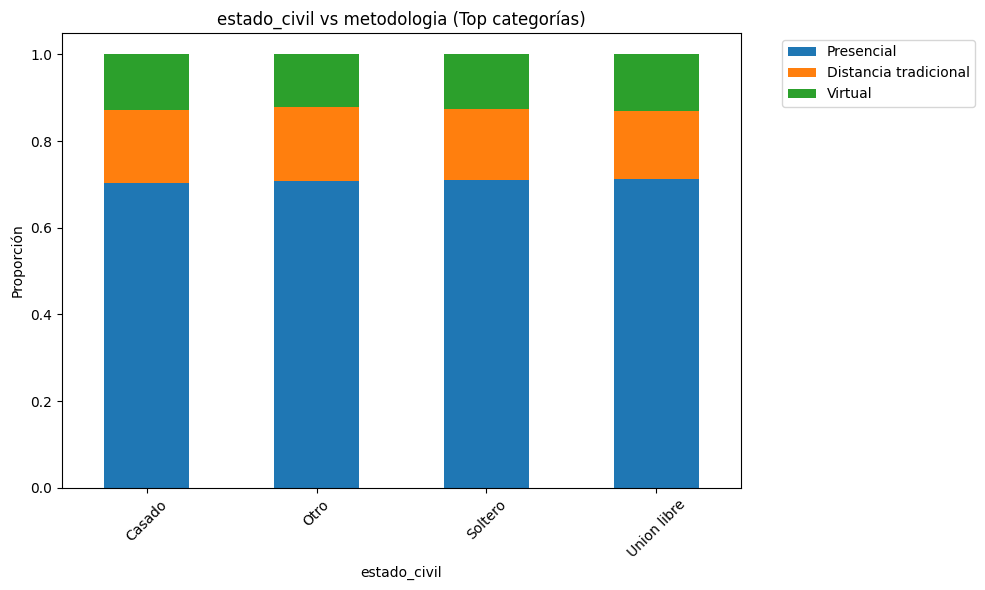

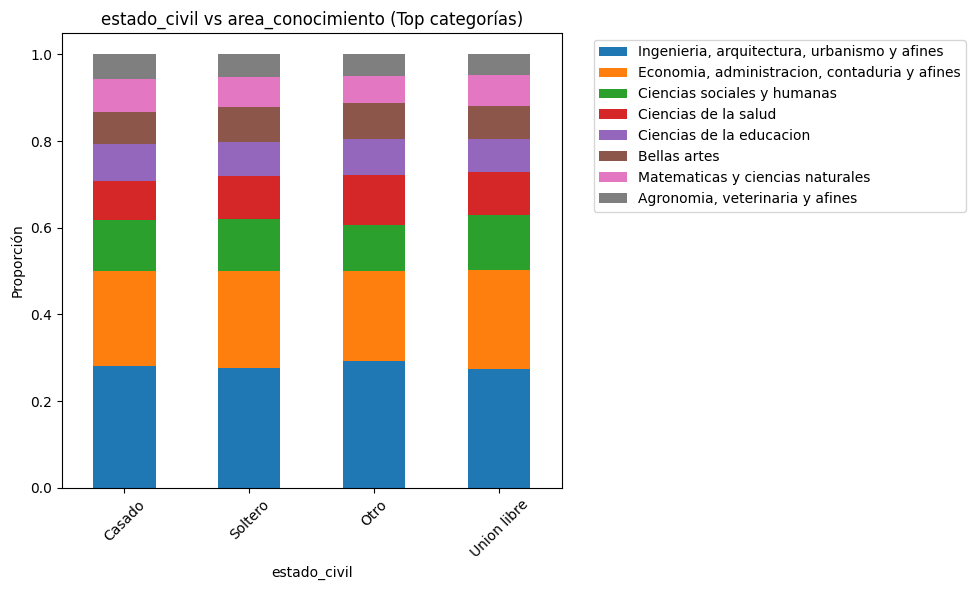

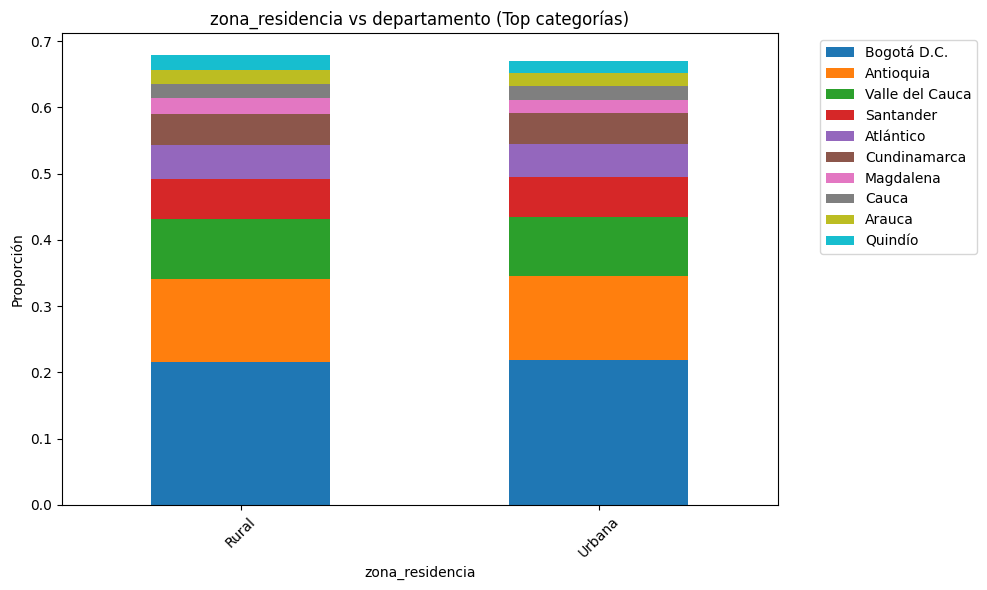

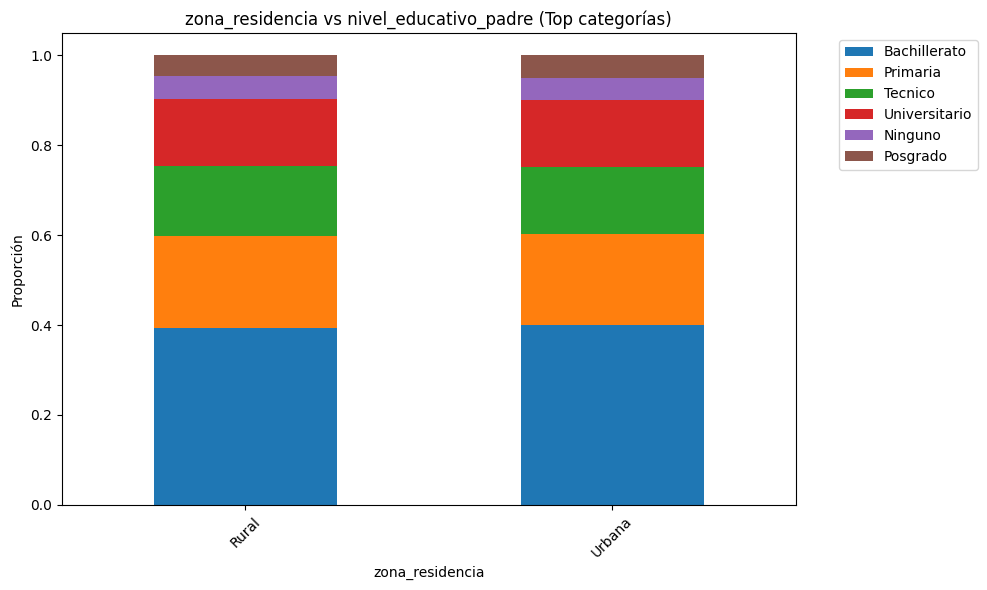

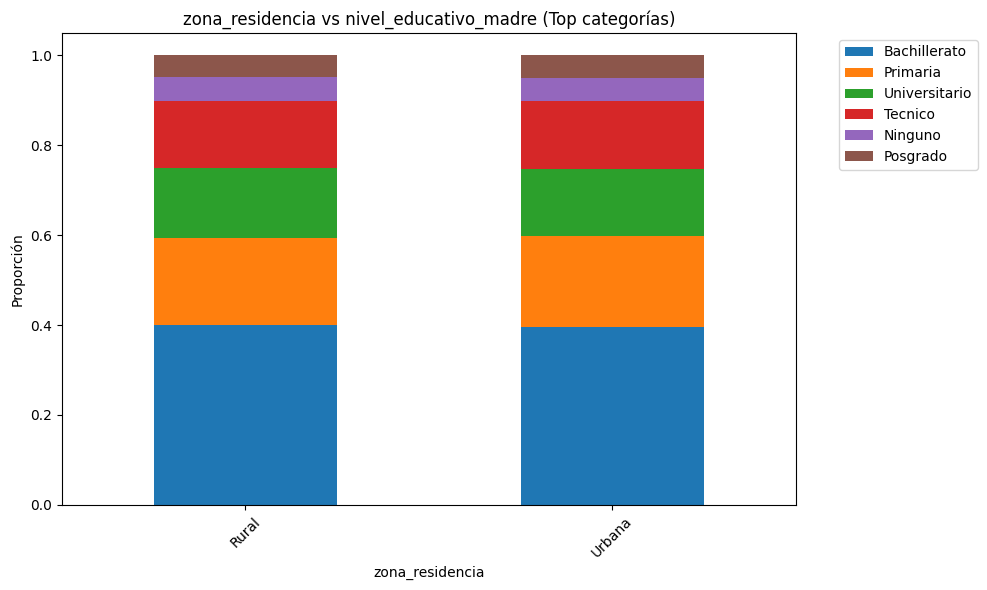

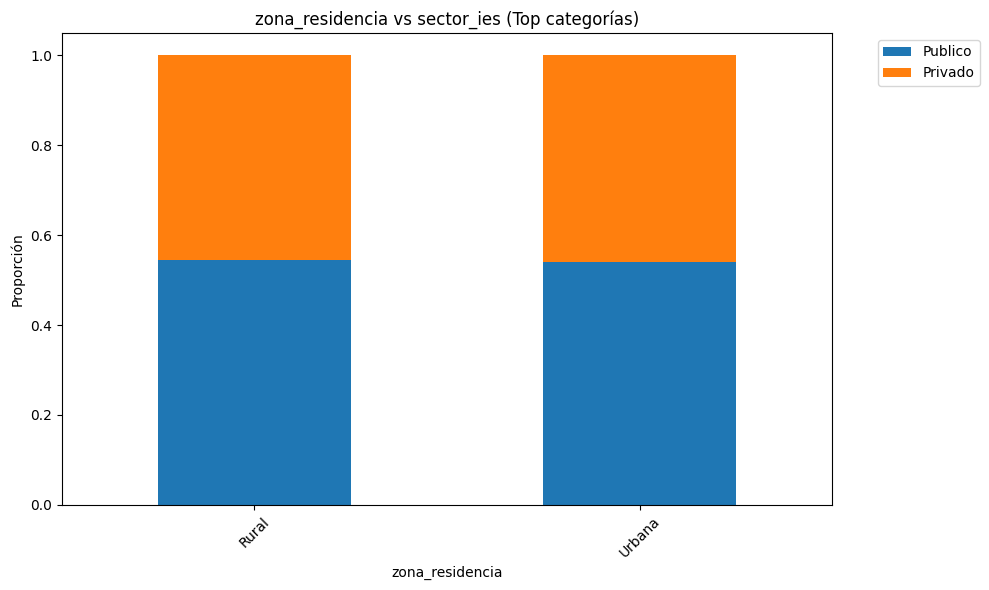

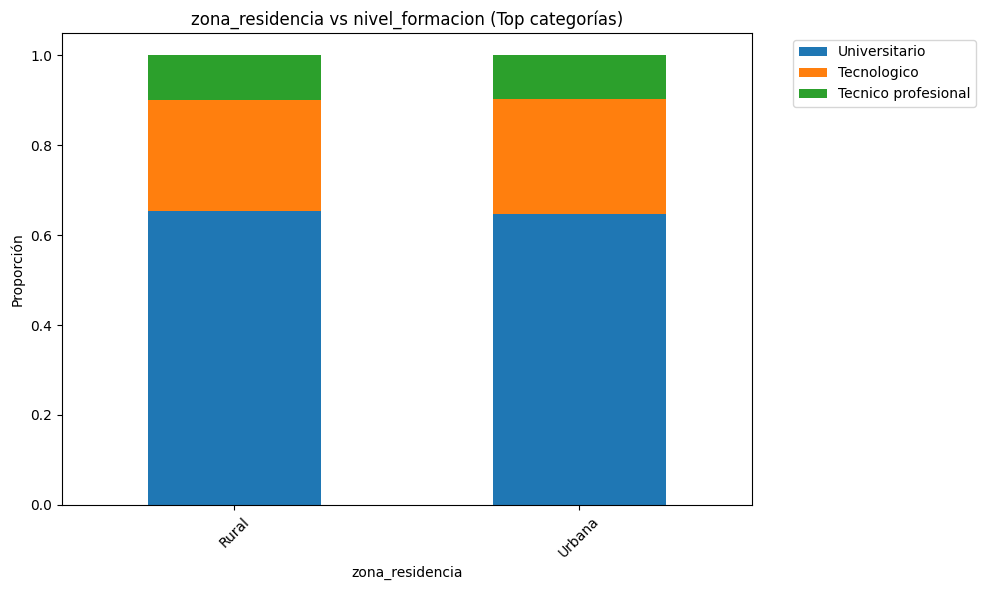

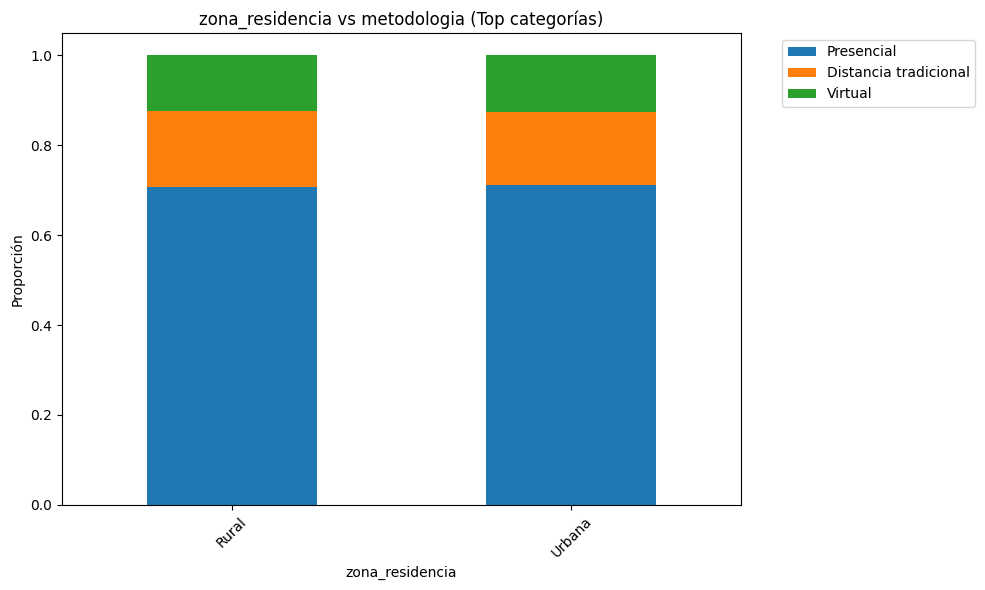

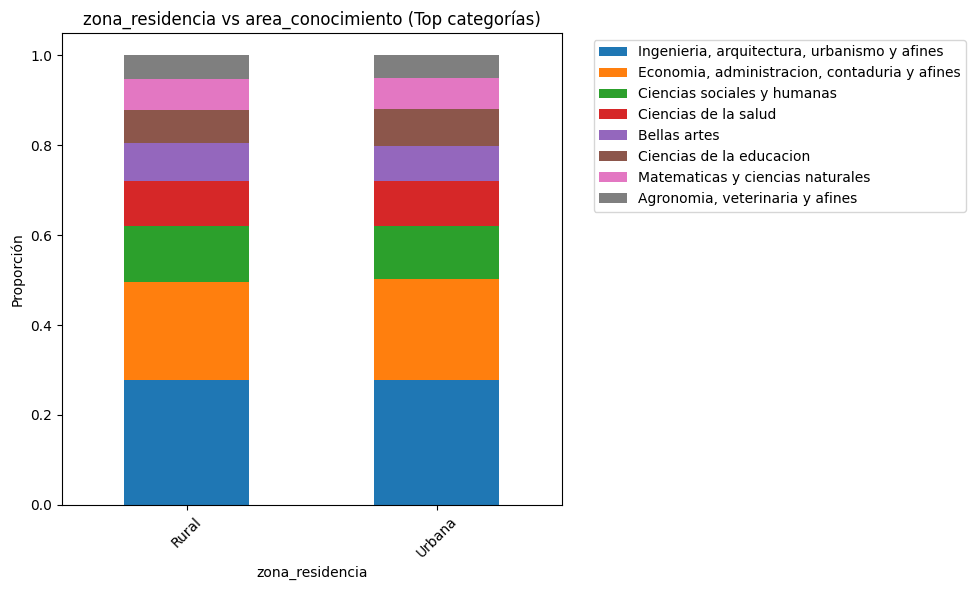

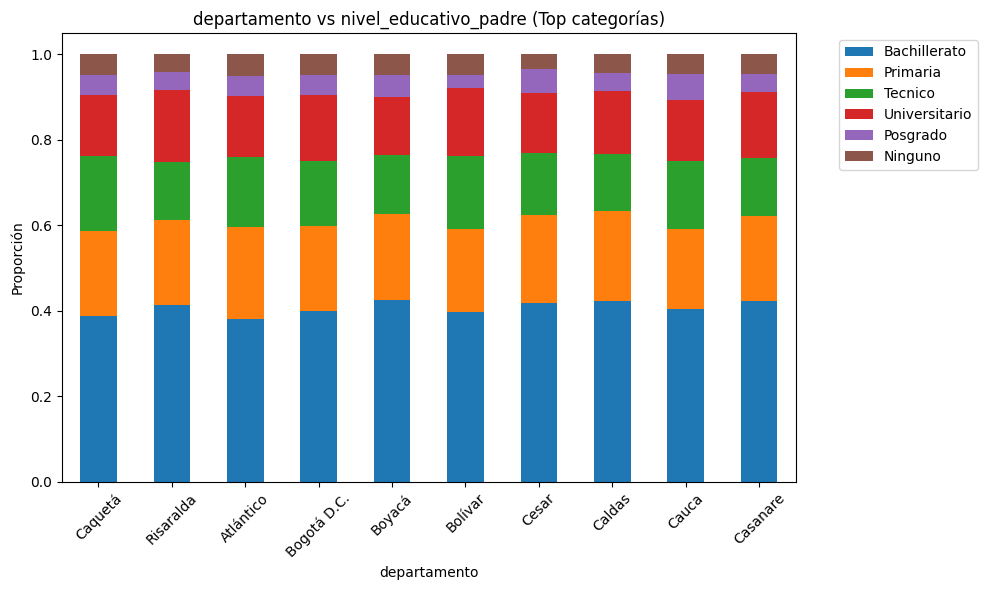

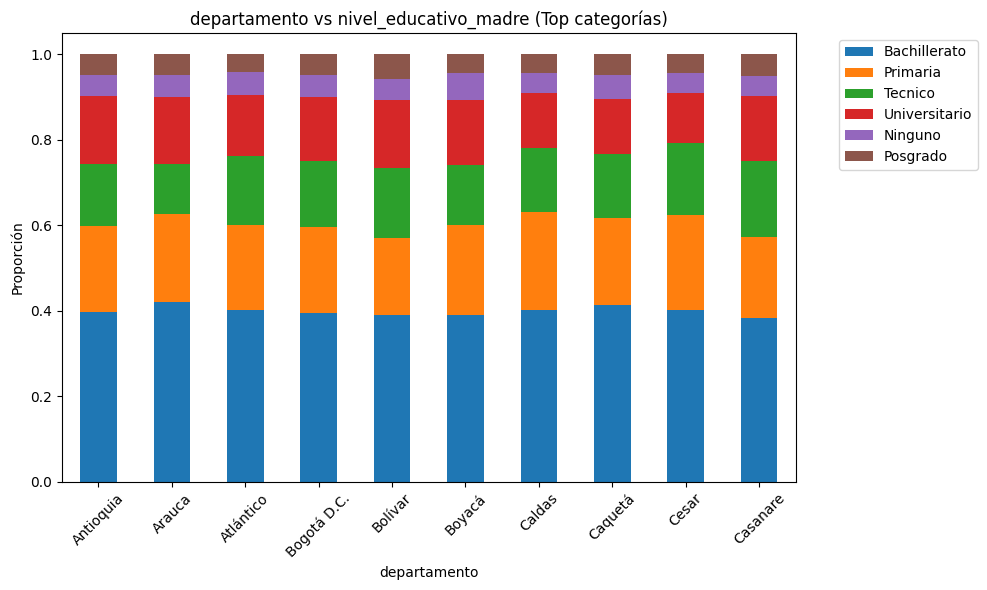

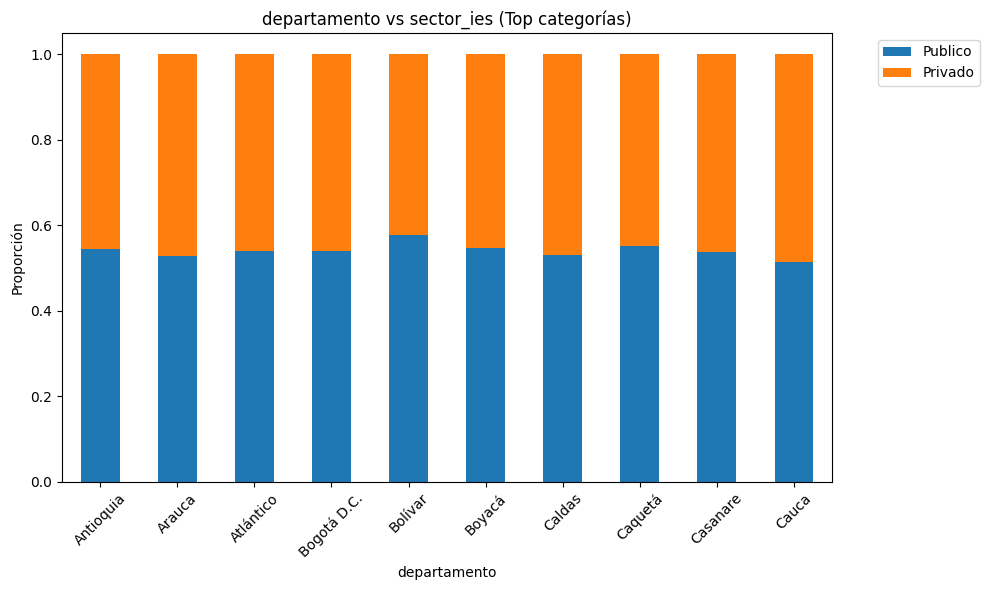

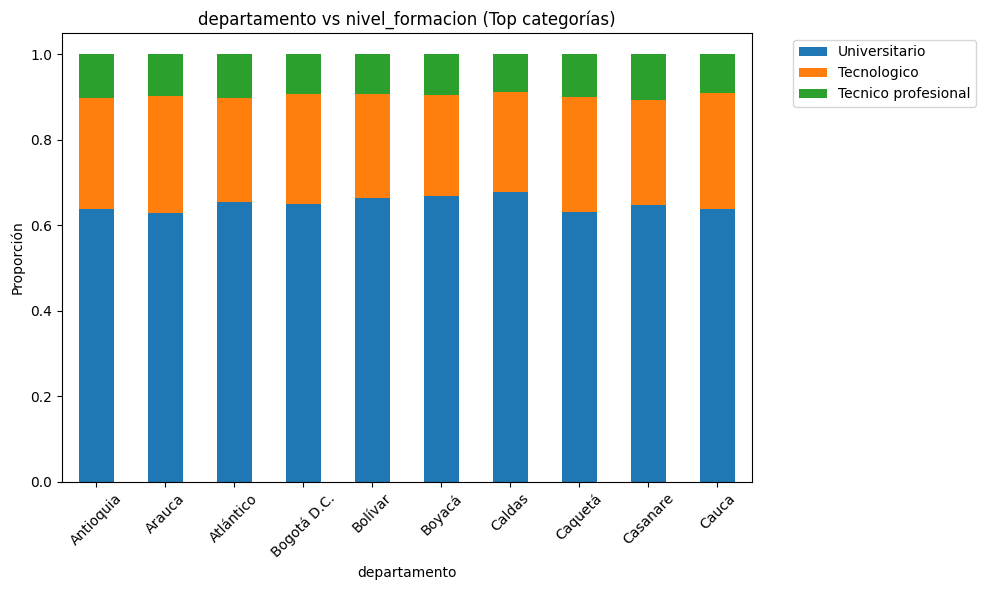

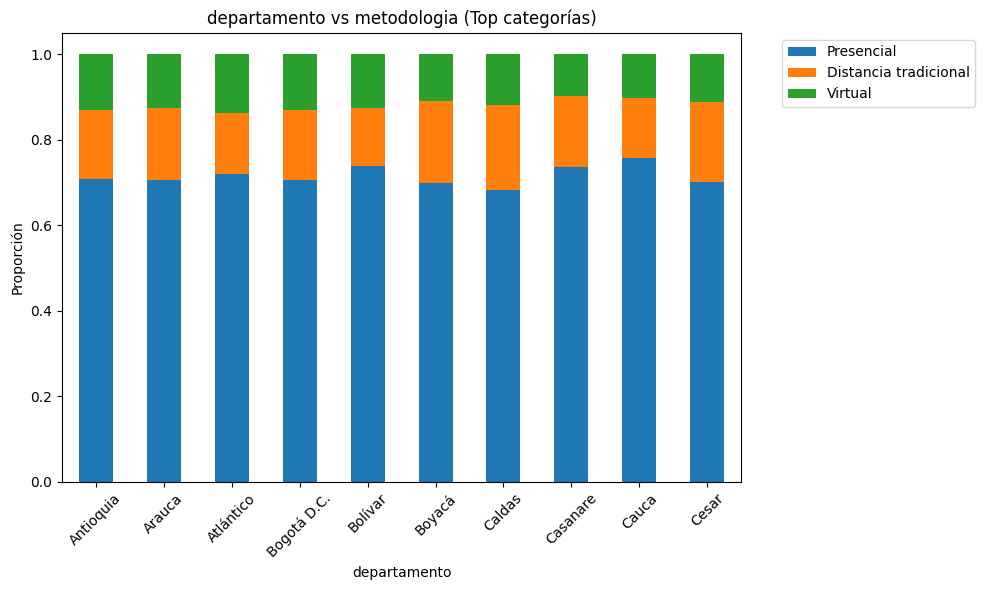

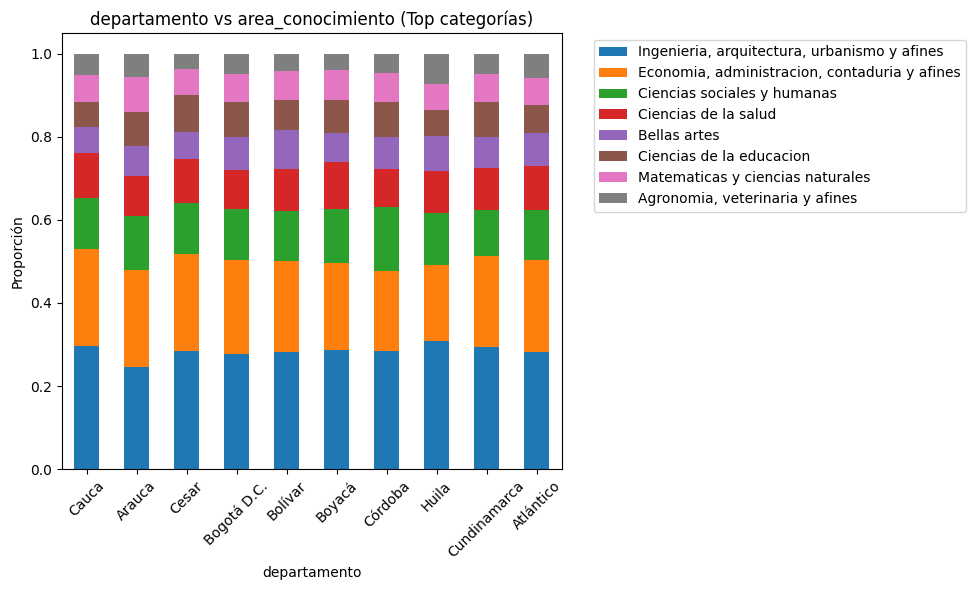

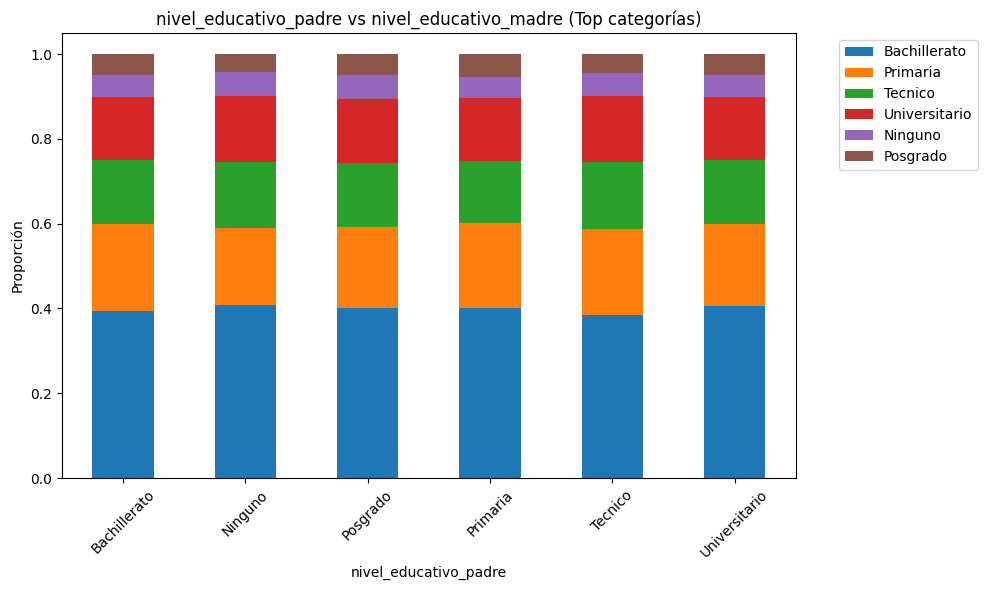

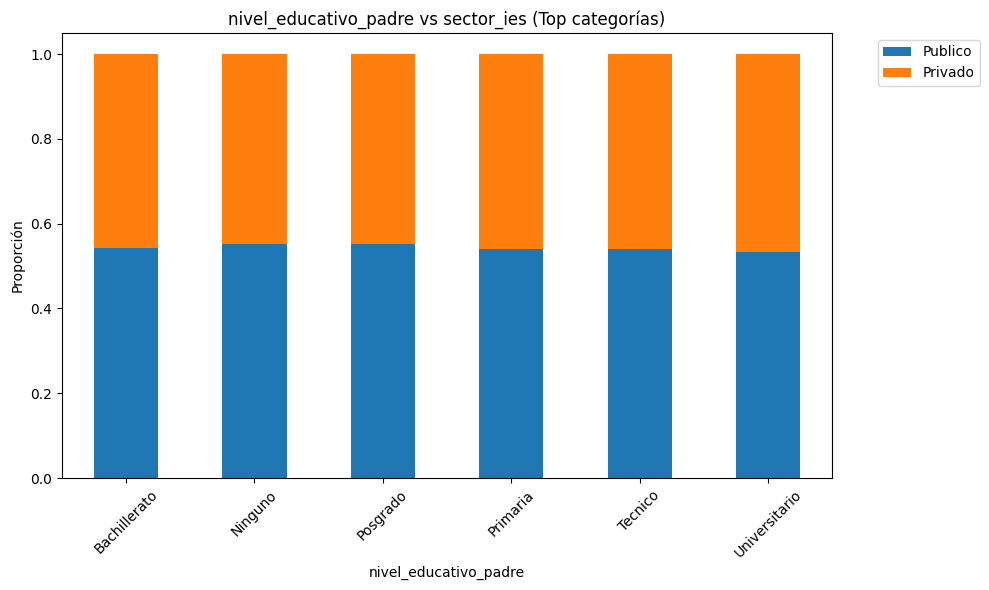

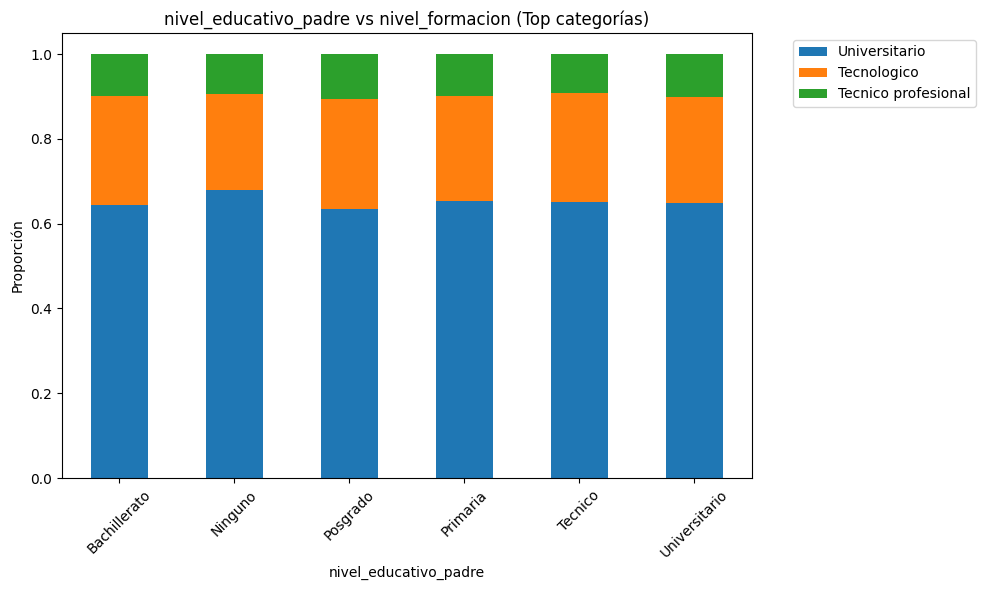

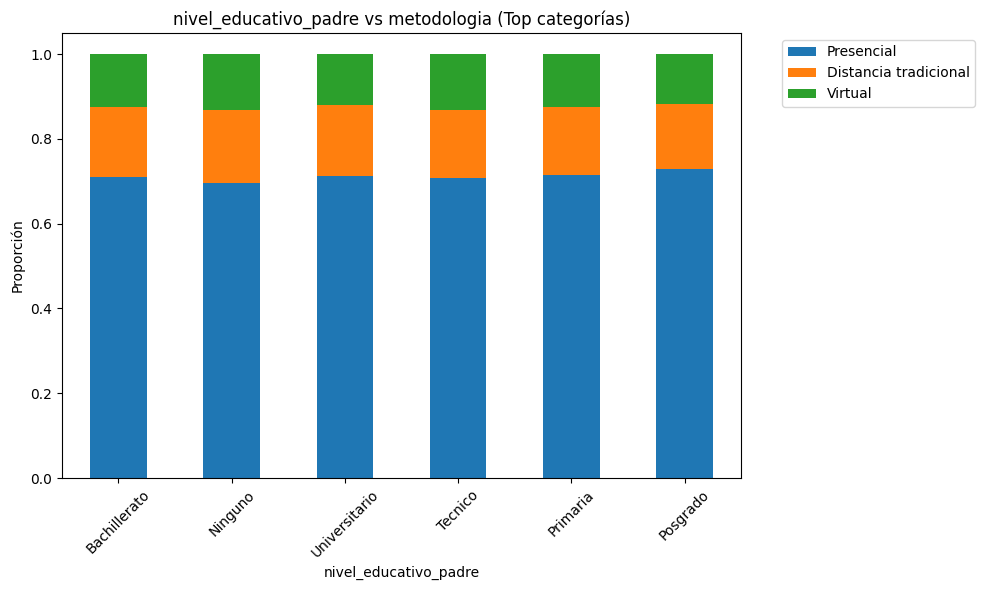

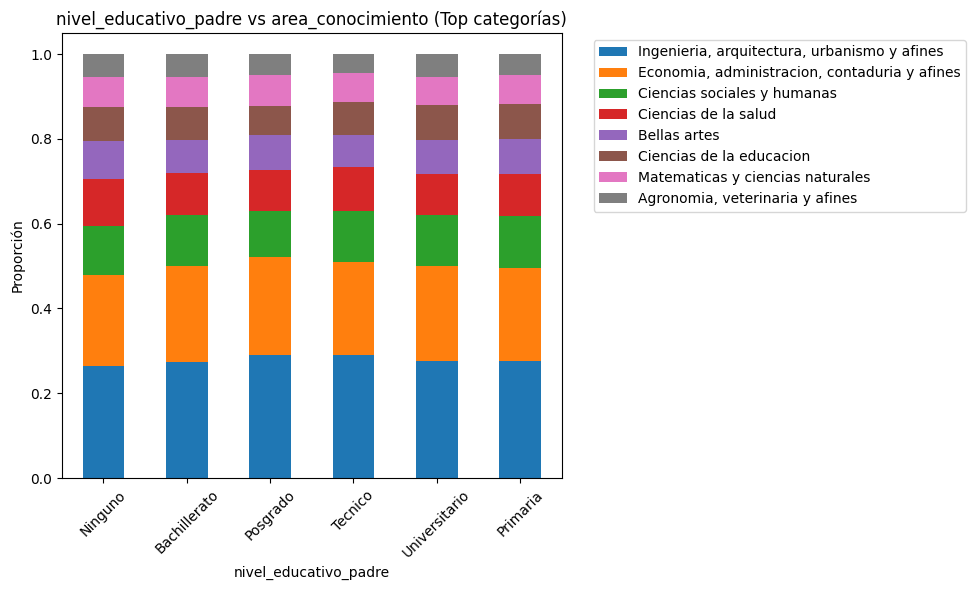

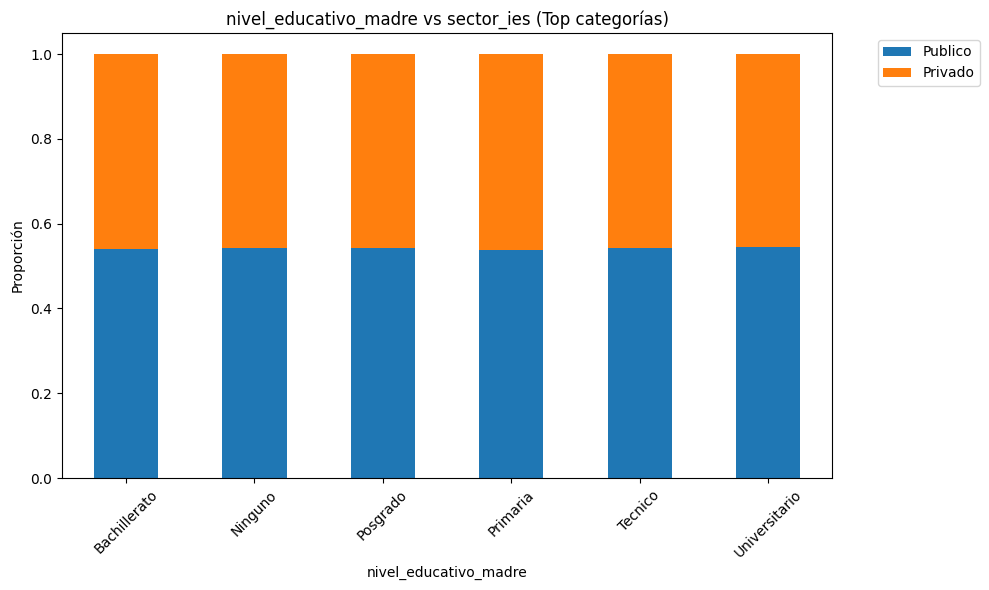

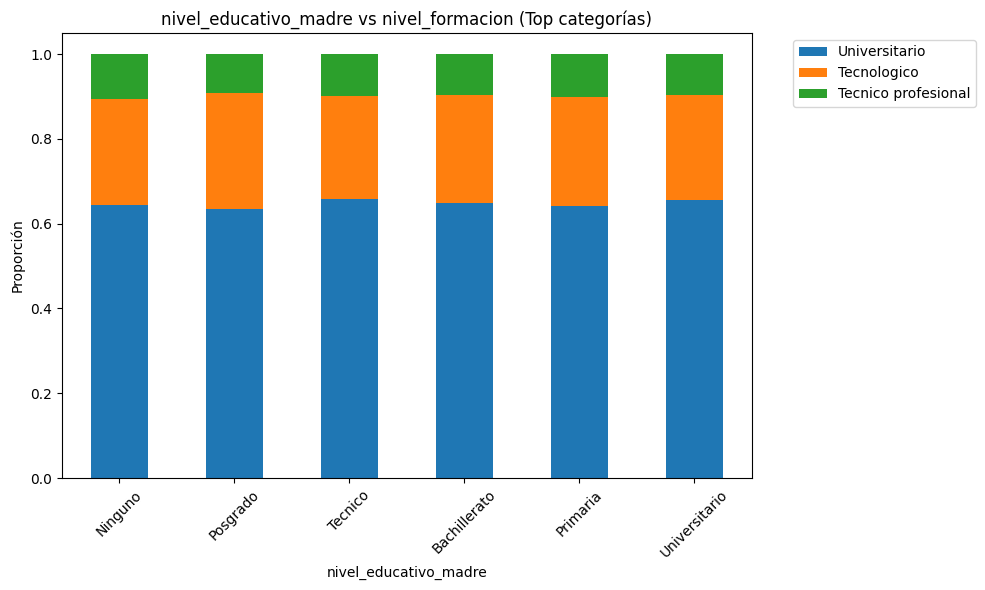

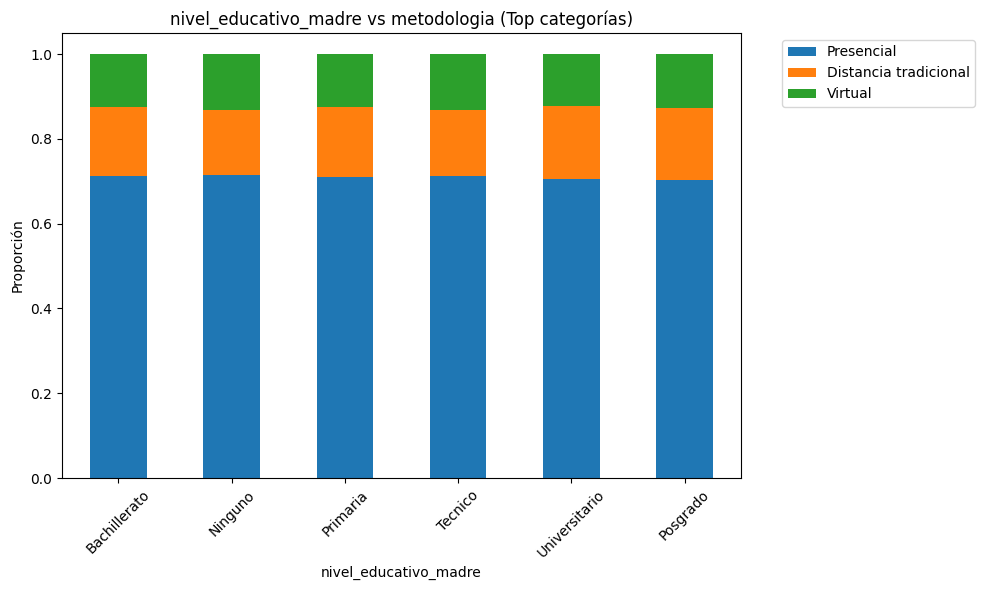

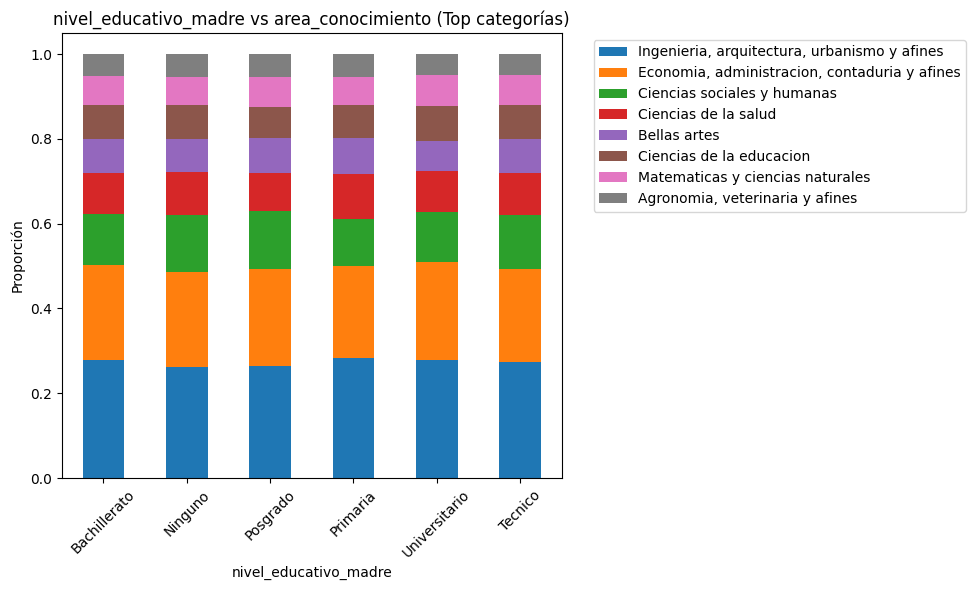

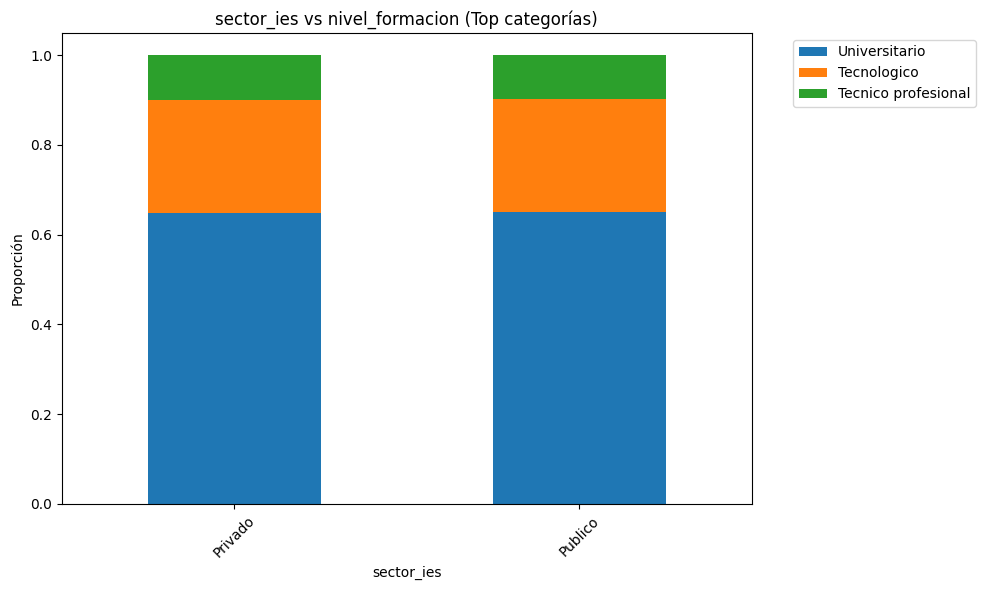

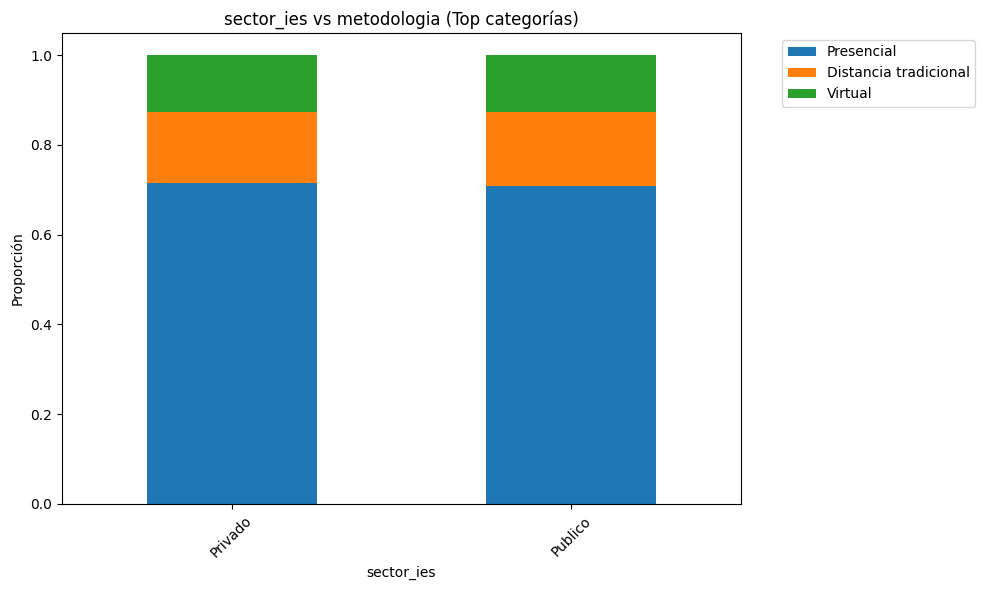

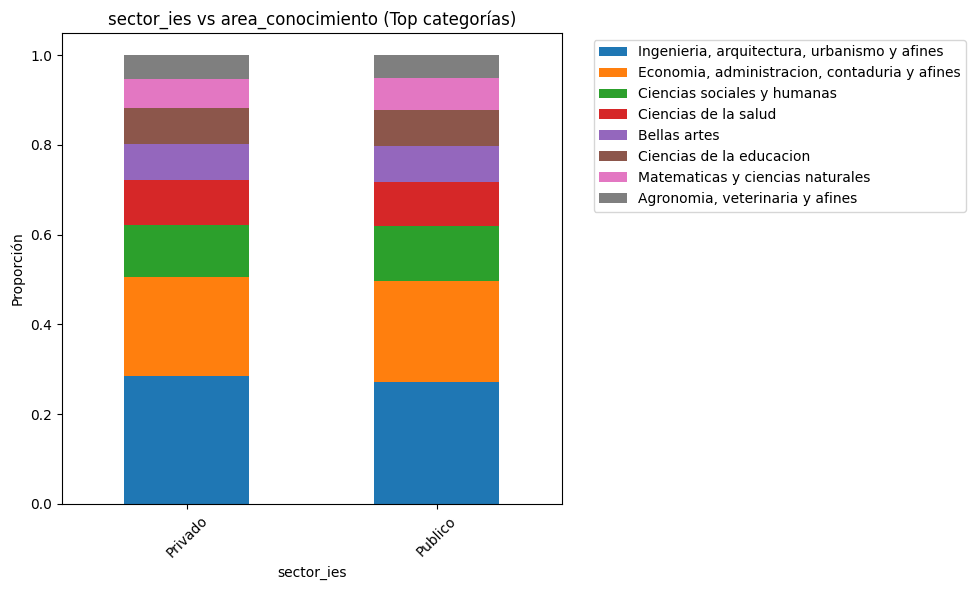

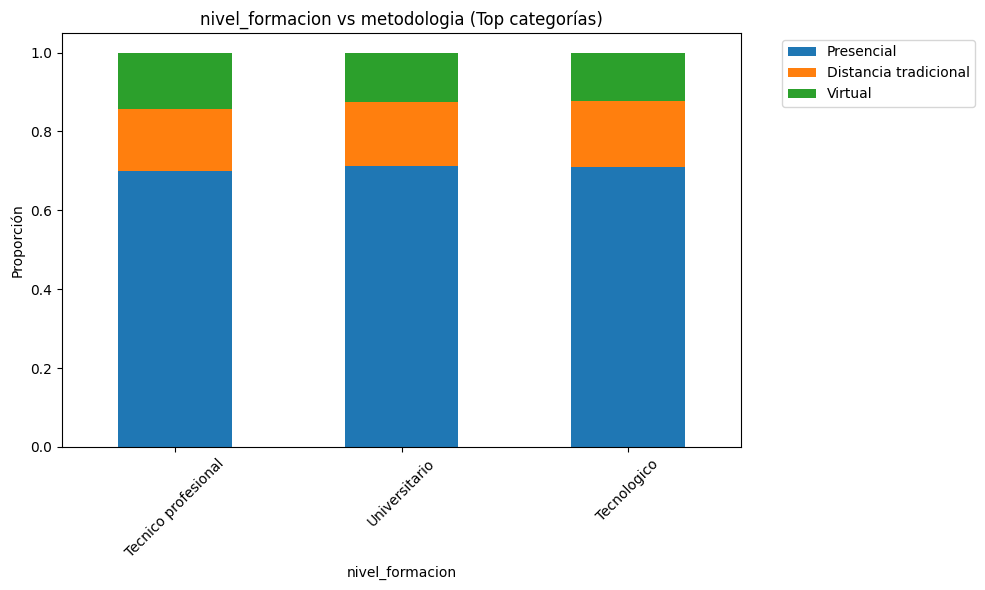

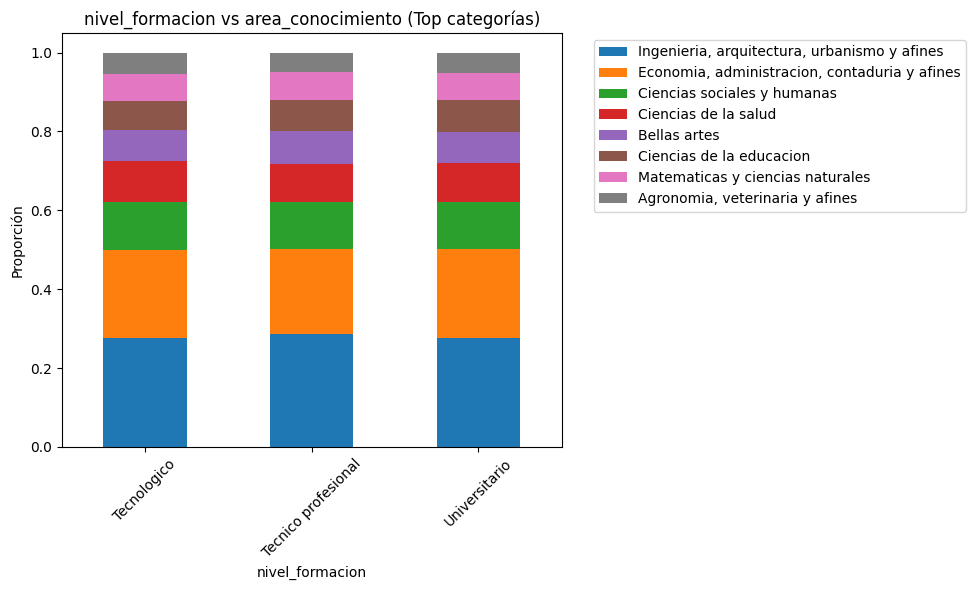

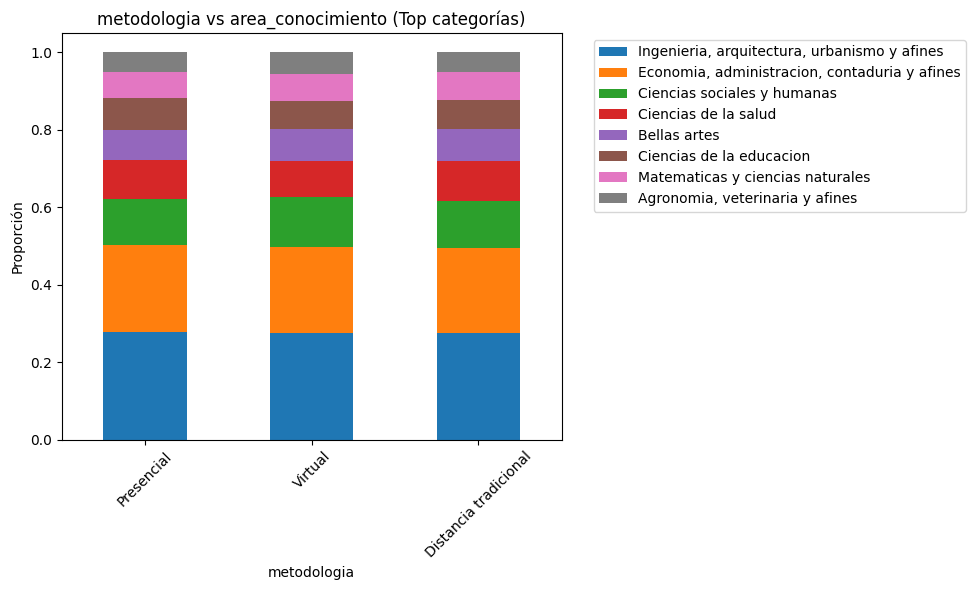

In [22]:
cat_cols = df.select_dtypes(include='object').columns

for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):

        col1 = cat_cols[i]
        col2 = cat_cols[j]

        # Tabla de contingencia en proporciones
        tabla = pd.crosstab(df[col1], df[col2], normalize='index')

        # Reducir complejidad: Top N filas (eje X)
        top_n_filas = tabla.sum(axis=1).sort_values(ascending=False).head(10).index
        tabla = tabla.loc[top_n_filas]

        # Reducir complejidad: Top N columnas (leyenda)
        top_n_cols = tabla.sum(axis=0).sort_values(ascending=False).head(10).index
        tabla = tabla[top_n_cols]

        # Ordenar filas para mejor visualización
        tabla = tabla.loc[tabla.sum(axis=1).sort_values(ascending=False).index]

        # Gráfico
        ax = tabla.plot(kind='bar', stacked=True, figsize=(10,6))

        plt.title(f'{col1} vs {col2} (Top categorías)')
        plt.xlabel(col1)
        plt.ylabel('Proporción')

        plt.xticks(rotation=45)

        # Leyenda afuera
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

        plt.tight_layout()
        plt.show()


## Relacion Entre Categoricas


In [23]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape

    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)

    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Solo variables categóricas
cat_cols = df.select_dtypes(include='object').columns

results = []

for col1, col2 in combinations(cat_cols, 2):
    v = cramers_v(df[col1], df[col2])
    results.append((col1, col2, v))

corr_df = pd.DataFrame(results, columns=['var1', 'var2', 'cramers_v'])
corr_df.sort_values('cramers_v', ascending=False)

,var1,var2,cramers_v
41,sector_ies,area_conocimiento,0.014597
28,departamento,metodologia,0.013855
26,departamento,sector_ies,0.012712
23,zona_residencia,area_conocimiento,0.012524
2,sexo,departamento,0.011027
13,estado_civil,sector_ies,0.010705
29,departamento,area_conocimiento,0.010192
42,nivel_formacion,metodologia,0.010040
9,estado_civil,zona_residencia,0.008312
38,nivel_educativo_madre,area_conocimiento,0.008104


# Estandarizar variables y sacar Dummies para modelos que lo necesitan

In [24]:
# df no tiene las variables estandarizadas
df.shape

(31567, 23)

In [25]:
df

,id_estudiante,anio_registro,sexo,edad_ingreso,estado_civil,zona_residencia,departamento,estrato_socioeconomico,trabaja_mientras_estudia,beneficiario_icetex,...,sector_ies,nivel_formacion,metodologia,area_conocimiento,semestre_cursado,promedio_academico,materias_reprobadas,distancia_hogar_ies_km,puntaje_icfes_percentil,desercion
0,20,2018,Hombre,20,Union libre,Urbana,Tolima,3,1,0,...,Publico,Tecnico profesional,Presencial,"Economia, administracion, contaduria y afines",3,1.85,1,6.76,74,1
1,19,2018,Hombre,20,Soltero,Rural,Valle del Cauca,1,0,0,...,Publico,Universitario,Presencial,Matematicas y ciencias naturales,3,4.29,2,4.43,55,0
2,18,2018,Mujer,22,Soltero,Rural,Nariño,4,1,0,...,Publico,Universitario,Presencial,Ciencias de la salud,1,2.75,4,1.77,69,1
3,17,2018,Hombre,21,Casado,Rural,Bogotá D.C.,2,0,1,...,Publico,Universitario,Presencial,"Economia, administracion, contaduria y afines",2,3.07,1,55.84,30,0
4,16,2018,Hombre,19,Soltero,Urbana,Bogotá D.C.,2,1,1,...,Privado,Tecnologico,Presencial,"Economia, administracion, contaduria y afines",1,3.90,2,2.86,23,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31562,31541,2023,Hombre,16,Soltero,Urbana,Valle del Cauca,2,0,0,...,Publico,Universitario,Presencial,"Economia, administracion, contaduria y afines",4,3.00,2,6.07,40,1
31563,31542,2023,Hombre,16,Union libre,Urbana,Bogotá D.C.,4,0,0,...,Publico,Universitario,Presencial,"Ingenieria, arquitectura, urbanismo y afines",4,4.87,0,21.23,15,0
31564,31543,2023,Mujer,21,Casado,Urbana,Bogotá D.C.,3,0,1,...,Publico,Tecnologico,Presencial,Matematicas y ciencias naturales,3,3.25,0,8.02,38,0
31565,31544,2023,Mujer,18,Soltero,Urbana,Antioquia,1,1,0,...,Privado,Tecnico profesional,Virtual,"Ingenieria, arquitectura, urbanismo y afines",3,4.47,1,10.52,61,0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31567 entries, 0 to 31566
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_estudiante             31567 non-null  int64  
 1   anio_registro             31567 non-null  int64  
 2   sexo                      31567 non-null  object 
 3   edad_ingreso              31567 non-null  int64  
 4   estado_civil              31567 non-null  object 
 5   zona_residencia           31567 non-null  object 
 6   departamento              31567 non-null  object 
 7   estrato_socioeconomico    31567 non-null  int64  
 8   trabaja_mientras_estudia  31567 non-null  int64  
 9   beneficiario_icetex       31567 non-null  int64  
 10  beneficiario_beca         31567 non-null  int64  
 11  nivel_educativo_padre     31567 non-null  object 
 12  nivel_educativo_madre     31567 non-null  object 
 13  sector_ies                31567 non-null  object 
 14  nivel_

In [27]:
# Guardar ID por separado
ids = df["id_estudiante"]

#Eliminar la columna que solo sirve como identificador
df_estandarizado = df.drop(columns=['id_estudiante'])

#Categorizar las varaibles para estandarizar cada una de la forma correcta - no se tiene en cuenta la variable objetivo

num_cols = [
    'edad_ingreso',
    'promedio_academico',
    'materias_reprobadas',
    'distancia_hogar_ies_km',
    'puntaje_icfes_percentil'
]

bin_cols = [
    'trabaja_mientras_estudia',
    'beneficiario_icetex',
    'beneficiario_beca'
]

cat_cols = [
    'sexo',
    'estado_civil',
    'zona_residencia',
    'departamento',
    'nivel_educativo_padre',
    'nivel_educativo_madre',
    'sector_ies',
    'nivel_formacion',
    'metodologia',
    'area_conocimiento'
]

ord_cols = [
    'semestre_cursado',
    'estrato_socioeconomico'
]

In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
        ('ord', StandardScaler(), ord_cols)
    ],
    remainder='passthrough'  # deja binarias tal cual
)

In [29]:
#Separa X y Y

X = df_estandarizado.drop(columns=['desercion'])
y = df_estandarizado['desercion']

In [ ]:
#Aplicar Transformacion

#X_transformed = preprocessor.fit_transform(X)

In [ ]:
#feature_names = preprocessor.get_feature_names_out()

#X_df = pd.DataFrame.sparse.from_spmatrix(
#    X_transformed,
#    columns=feature_names
#)

In [30]:
X_transformed = preprocessor.fit_transform(X)

X_df = pd.DataFrame(
    X_transformed.toarray(),
    columns=preprocessor.get_feature_names_out()
)

In [31]:
X_df

,num__edad_ingreso,num__promedio_academico,num__materias_reprobadas,num__distancia_hogar_ies_km,num__puntaje_icfes_percentil,cat__sexo_Mujer,cat__estado_civil_Otro,cat__estado_civil_Soltero,cat__estado_civil_Union libre,cat__zona_residencia_Urbana,...,cat__area_conocimiento_Ciencias sociales y humanas,"cat__area_conocimiento_Economia, administracion, contaduria y afines","cat__area_conocimiento_Ingenieria, arquitectura, urbanismo y afines",cat__area_conocimiento_Matematicas y ciencias naturales,ord__semestre_cursado,ord__estrato_socioeconomico,remainder__anio_registro,remainder__trabaja_mientras_estudia,remainder__beneficiario_icetex,remainder__beneficiario_beca
0,0.096372,-1.741349,-0.235093,-0.392424,1.337827,0.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,-0.367429,0.292227,2018.0,1.0,0.0,1.0
1,0.096372,1.361489,0.700389,-0.528823,0.453778,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,-0.367429,-1.349624,2018.0,0.0,0.0,1.0
2,0.797579,-0.596860,2.571352,-0.684540,1.105182,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,-1.208092,1.113153,2018.0,1.0,0.0,0.0
3,0.446975,-0.189930,-0.235093,2.480732,-0.709443,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,-0.787761,-0.528698,2018.0,0.0,1.0,0.0
4,-0.254231,0.865543,0.700389,-0.620731,-1.035145,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,-1.208092,-0.528698,2018.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31562,-1.306040,-0.278946,0.700389,-0.432817,-0.244155,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.052903,-0.528698,2023.0,0.0,0.0,0.0
31563,-1.306040,2.099048,-1.170574,0.454653,-1.407376,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.052903,1.113153,2023.0,0.0,0.0,0.0
31564,0.446975,0.038968,-1.170574,-0.318663,-0.337212,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,-0.367429,0.292227,2023.0,0.0,1.0,0.0
31565,-0.604834,1.590386,-0.235093,-0.172313,0.732951,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,-0.367429,-1.349624,2023.0,1.0,0.0,1.0


In [32]:
X_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31567 entries, 0 to 31566
Data columns (total 64 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   num__edad_ingreso                                                     31567 non-null  float64
 1   num__promedio_academico                                               31567 non-null  float64
 2   num__materias_reprobadas                                              31567 non-null  float64
 3   num__distancia_hogar_ies_km                                           31567 non-null  float64
 4   num__puntaje_icfes_percentil                                          31567 non-null  float64
 5   cat__sexo_Mujer                                                       31567 non-null  float64
 6   cat__estado_civil_Otro                                                31567 non-null  float64


# Inicialización de Modelos

## Partición de datos

In [33]:
# 1. Train + Test
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X_df,
    y,
    ids,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", len(X_train))
print("Test:", len(X_test))

Train: 25253
Test: 6314


## Regresión Logistica

Fitting 5 folds for each of 8 candidates, totalling 40 fits

🔵 MEJORES HIPERPARÁMETROS:
{'model__C': 0.1, 'model__penalty': 'l1'}

🔵 MEJOR CV AUC:
0.8688412695598092

Número óptimo de variables: 19

===== MÉTRICAS LOGÍSTICA OPTIMIZADA =====
Accuracy: 0.7874564459930313
Balanced Accuracy: 0.7888302813874909
F1: 0.6815377313716184
ROC-AUC: 0.863930096798983

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.90      0.79      0.84      4501
           1       0.60      0.79      0.68      1813

    accuracy                           0.79      6314
   macro avg       0.75      0.79      0.76      6314
weighted avg       0.82      0.79      0.79      6314



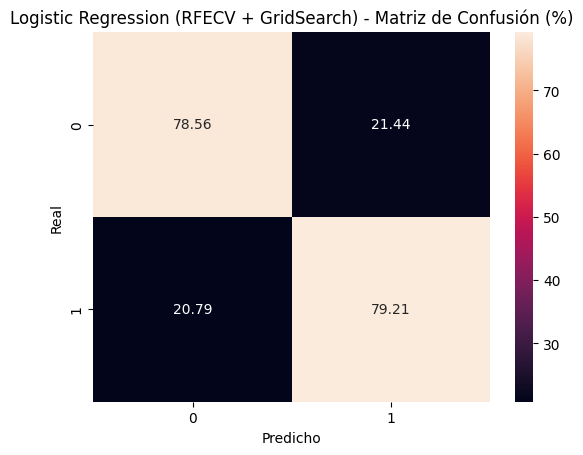

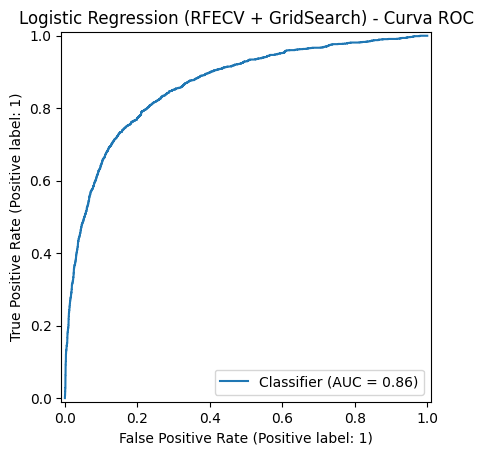


===== IMPORTANCIA =====
                                 feature  importance  odds_ratio
16   remainder__trabaja_mientras_estudia    0.563543    1.756886
1               num__materias_reprobadas    0.513281    1.670764
12   cat__nivel_educativo_madre_Posgrado    0.051444    1.052790
5                cat__departamento_Cauca    0.043723    1.044693
7                cat__departamento_Chocó    0.000000    1.000000
8           cat__departamento_La Guajira    0.000000    1.000000
9            cat__departamento_Magdalena    0.000000    1.000000
6                cat__departamento_Cesar   -0.020994    0.979224
10  cat__departamento_Norte de Santander   -0.066518    0.935646
15           ord__estrato_socioeconomico   -0.148001    0.862431
3                        cat__sexo_Mujer   -0.158321    0.853576
11           cat__departamento_Risaralda   -0.165151    0.847766
4            cat__zona_residencia_Urbana   -0.180669    0.834711
2           num__puntaje_icfes_percentil   -0.185106    0.831016


In [ ]:
# =========================
# 1. CROSS VALIDATION SETUP
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1052026)

# =========================
# 2. MODELO BASE
# =========================
base_model = LogisticRegression(
    solver="liblinear",
    max_iter=1000,
    class_weight='balanced'
)

# =========================
# 3. RFECV (SELECCIÓN VARIABLES)
# =========================
rfecv = RFECV(
    estimator=base_model,
    step=1,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

# =========================
# 4. PIPELINE
# =========================
pipeline = Pipeline([
    ("feature_selection", rfecv),
    ("model", base_model)
])

# =========================
# 5. GRID DE HIPERPARÁMETROS
# =========================
param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l1", "l2"]
}

# =========================
# 6. GRID SEARCH
# =========================
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

# =========================
# 7. MEJOR MODELO
# =========================
best_model = grid_search.best_estimator_

print("\n🔵 MEJORES HIPERPARÁMETROS:")
print(grid_search.best_params_)

print("\n🔵 MEJOR CV AUC:")
print(grid_search.best_score_)

# MEJORES HIPERPARÁMETROS:
#{'model__C': 0.1, 'model__penalty': 'l1'}

# =========================
# 8. VARIABLES SELECCIONADAS
# =========================
rfecv_fitted = best_model.named_steps["feature_selection"]

feature_names = X_train.columns.to_numpy()
selected_features = feature_names[rfecv_fitted.support_]

print("\nNúmero óptimo de variables:", rfecv_fitted.n_features_)

# =========================
# 9. PREDICCIONES EN TEST
# =========================
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# =========================
# 10. MÉTRICAS
# =========================
print("\n===== MÉTRICAS LOGÍSTICA OPTIMIZADA =====")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred))

# =========================
# 11. MATRIZ DE CONFUSIÓN (%)
# =========================
cm = confusion_matrix(y_test, y_pred)
cm_percent = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure()
sns.heatmap(cm_percent, annot=True, fmt=".2f")
plt.title("Logistic Regression (RFECV + GridSearch) - Matriz de Confusión (%)")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

# =========================
# 12. CURVA ROC
# =========================
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Logistic Regression (RFECV + GridSearch) - Curva ROC")
plt.show()

# =========================
# 13. IMPORTANCIA (COEFICIENTES)
# =========================
model_final = best_model.named_steps["model"]
coef = model_final.coef_[0]

df_importance = pd.DataFrame({
    "feature": selected_features,
    "importance": coef,
    "odds_ratio": np.exp(coef)
}).sort_values(by="importance", ascending=False)

print("\n===== IMPORTANCIA =====")
print(df_importance.head(15))

In [ ]:
y_pred_log = best_model.predict(X_test)
y_proba_log = best_model.predict_proba(X_test)[:, 1]

## Random Forest

Fitting 5 folds for each of 108 candidates, totalling 540 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



🔵 MEJORES HIPERPARÁMETROS:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 500}

🔵 MEJOR CV AUC:
0.8837072616269559

===== MÉTRICAS RANDOM FOREST OPTIMIZADO =====
Accuracy: 0.807887234716503
Balanced Accuracy: 0.7985488424279804
F1: 0.6989327376520228
ROC-AUC: 0.8782506259257455

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.90      0.82      0.86      4501
           1       0.64      0.78      0.70      1813

    accuracy                           0.81      6314
   macro avg       0.77      0.80      0.78      6314
weighted avg       0.82      0.81      0.81      6314



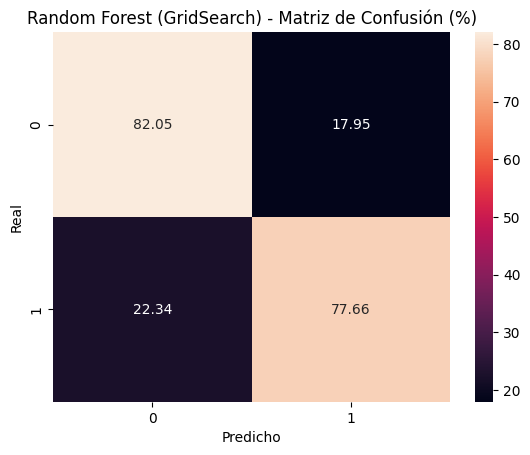

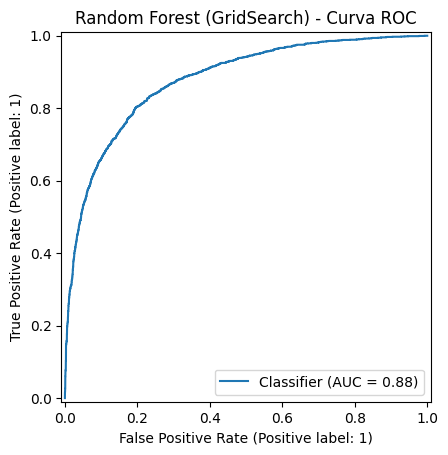


===== TOP VARIABLES IMPORTANTES =====
                                feature  importance
1               num__promedio_academico    0.647415
2              num__materias_reprobadas    0.145588
4          num__puntaje_icfes_percentil    0.026455
58                ord__semestre_cursado    0.023158
61  remainder__trabaja_mientras_estudia    0.022749
3           num__distancia_hogar_ies_km    0.019413
49          cat__metodologia_Presencial    0.011203
59          ord__estrato_socioeconomico    0.010575
0                     num__edad_ingreso    0.010345
60             remainder__anio_registro    0.007782
5                       cat__sexo_Mujer    0.003806
63         remainder__beneficiario_beca    0.003719
9           cat__zona_residencia_Urbana    0.003364
62       remainder__beneficiario_icetex    0.003358
50             cat__metodologia_Virtual    0.003299


In [ ]:
# =========================
# 1. CROSS VALIDATION SETUP
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1052026)

# =========================
# 2. MODELO BASE
# =========================
rf = RandomForestClassifier(
    random_state=1052026,
    n_jobs=1,
    class_weight='balanced'
)

# =========================
# 3. GRID DE HIPERPARÁMETROS
# =========================
param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# los mejores hiperparametros son: 🔵 MEJORES HIPERPARÁMETROS:{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 500}

# =========================
# 4. GRID SEARCH CV
# =========================
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

# Mejor modelo
best_rf = grid_search.best_estimator_

print("\n🔵 MEJORES HIPERPARÁMETROS:")
print(grid_search.best_params_)

print("\n🔵 MEJOR CV AUC:")
print(grid_search.best_score_)

# =========================
# 5. PREDICCIONES EN TEST
# =========================
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

# =========================
# 6. MÉTRICAS (IGUAL QUE LOGÍSTICA)
# =========================
print("\n===== MÉTRICAS RANDOM FOREST OPTIMIZADO =====")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred))

# =========================
# 7. MATRIZ DE CONFUSIÓN (%)
# =========================
cm = confusion_matrix(y_test, y_pred)
cm_percent = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure()
sns.heatmap(cm_percent, annot=True, fmt=".2f")
plt.title("Random Forest (GridSearch) - Matriz de Confusión (%)")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

# =========================
# 8. CURVA ROC
# =========================
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Random Forest (GridSearch) - Curva ROC")
plt.show()

# =========================
# 9. IMPORTANCIA DE VARIABLES
# =========================
df_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_rf.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\n===== TOP VARIABLES IMPORTANTES =====")
print(df_importance.head(15))

In [ ]:
y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

## XG - Boost

Fitting 5 folds for each of 8 candidates, totalling 40 fits

🔵 MEJORES HIPERPARÁMETROS:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}

🔵 MEJOR CV AUC:
0.8872439824336869

===== MÉTRICAS XGBOOST OPTIMIZADO =====
Accuracy: 0.8150142540386442
Balanced Accuracy: 0.8051947272120568
F1: 0.7082917082917083
ROC-AUC: 0.8822870519795013

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.90      0.83      0.86      4501
           1       0.65      0.78      0.71      1813

    accuracy                           0.82      6314
   macro avg       0.78      0.81      0.79      6314
weighted avg       0.83      0.82      0.82      6314



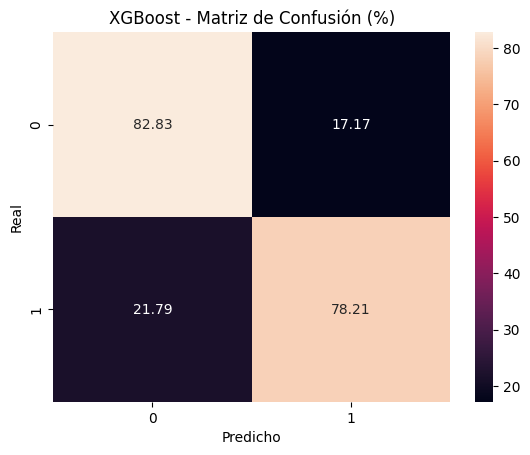

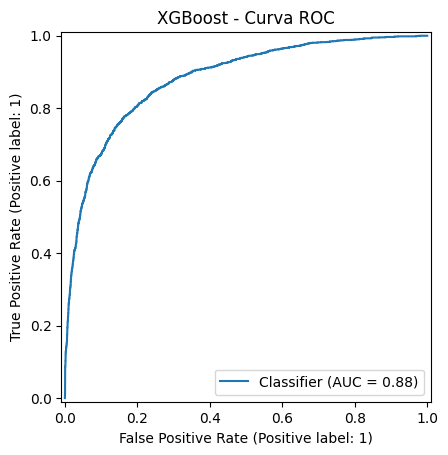


===== TOP VARIABLES IMPORTANTES =====
                                              feature  importance
1                             num__promedio_academico    0.245657
2                            num__materias_reprobadas    0.091727
61                remainder__trabaja_mientras_estudia    0.031310
49                        cat__metodologia_Presencial    0.026312
58                              ord__semestre_cursado    0.020004
63                       remainder__beneficiario_beca    0.015739
4                        num__puntaje_icfes_percentil    0.014693
59                        ord__estrato_socioeconomico    0.014319
62                     remainder__beneficiario_icetex    0.013640
5                                     cat__sexo_Mujer    0.012209
24                       cat__departamento_La Guajira    0.011966
9                         cat__zona_residencia_Urbana    0.011801
44                 cat__nivel_educativo_madre_Tecnico    0.011341
55  cat__area_conocimiento_Economia, 

In [34]:
# =========================
# 1. CROSS VALIDATION
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1052026)

# =========================
# 2. MODELO BASE
# =========================
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

xgb = XGBClassifier(
    random_state=1052026,
    eval_metric='logloss',
    n_jobs=1,
    scale_pos_weight=scale_pos_weight
)

# =========================
# 3. GRID PEQUEÑO (CLAVE)
# =========================
param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [4, 6],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}

# los mejores hiperparametros son:{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}

# =========================
# 4. GRID SEARCH
# =========================
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

# =========================
# 5. MEJOR MODELO
# =========================
best_xgb = grid_search.best_estimator_

print("\n🔵 MEJORES HIPERPARÁMETROS:")
print(grid_search.best_params_)

print("\n🔵 MEJOR CV AUC:")
print(grid_search.best_score_)

# =========================
# 6. PREDICCIONES TEST
# =========================
y_pred = best_xgb.predict(X_test)
y_proba = best_xgb.predict_proba(X_test)[:, 1]

# =========================
# 7. MÉTRICAS
# =========================
print("\n===== MÉTRICAS XGBOOST OPTIMIZADO =====")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred))

# =========================
# 8. MATRIZ DE CONFUSIÓN (%)
# =========================
cm = confusion_matrix(y_test, y_pred)
cm_percent = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure()
sns.heatmap(cm_percent, annot=True, fmt=".2f")
plt.title("XGBoost - Matriz de Confusión (%)")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

# =========================
# 9. CURVA ROC
# =========================
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("XGBoost - Curva ROC")
plt.show()

# =========================
# 10. IMPORTANCIA VARIABLES
# =========================
df_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_xgb.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\n===== TOP VARIABLES IMPORTANTES =====")
print(df_importance.head(15))

In [35]:
y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

# Comparar Modelos

In [36]:
# =========================
# TABLA COMPARATIVA MODELOS
# =========================

from sklearn.metrics import precision_score, recall_score

results = pd.DataFrame({
    "Modelo": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],

    "Balanced Accuracy": [
        balanced_accuracy_score(y_test, y_pred_log),
        balanced_accuracy_score(y_test, y_pred_rf),
        balanced_accuracy_score(y_test, y_pred_xgb)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],

    "ROC AUC": [
        roc_auc_score(y_test, y_proba_log),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_xgb)
    ],

    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],

    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ]
})

results = results.sort_values(by="ROC AUC", ascending=False)

print(results)

NameError: name 'y_pred_log' is not defined

In [ ]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8,6))

RocCurveDisplay.from_predictions(
    y_test,
    y_proba_log,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_proba_rf,
    name="Random Forest"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_proba_xgb,
    name="XGBoost"
)

plt.title("Comparación Curvas ROC")
plt.plot([0,1],[0,1],'k--')
plt.show()

In [ ]:
results_plot = results.set_index("Modelo")

results_plot.plot(kind="bar", figsize=(12,6))

plt.title("Comparación de métricas por modelo")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
modelos = {
    "Logistic Regression": y_pred_log,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

for nombre, pred in modelos.items():
    cm = confusion_matrix(y_test, pred)
    cm_percent = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

    plt.figure(figsize=(5,4))
    sns.heatmap(cm_percent, annot=True, fmt=".2f", cmap="Blues")
    plt.title(f"{nombre} - Matriz de Confusión (%)")
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.show()

In [ ]:
ranking = results.copy()

ranking["Ranking ROC AUC"] = ranking["ROC AUC"].rank(ascending=False)
ranking["Ranking F1"] = ranking["F1 Score"].rank(ascending=False)
ranking["Ranking Recall"] = ranking["Recall"].rank(ascending=False)
ranking["Ranking Balanced Accuracy"] = ranking["Balanced Accuracy"].rank(ascending=False)

ranking["Ranking Promedio"] = ranking[
    [
        "Ranking ROC AUC",
        "Ranking F1",
        "Ranking Recall",
        "Ranking Balanced Accuracy"
    ]
].mean(axis=1)

ranking = ranking.sort_values("Ranking Promedio")

ranking

In [ ]:
mejor_modelo = ranking.iloc[0]["Modelo"]

print("El mejor modelo general es:", mejor_modelo)

# Exportar informacion para dashboard

In [37]:
import pickle

modelo_final = {
    "xgboost": best_xgb,
    "preprocessor": preprocessor
}

with open("modelo_xgboost_desercion.pkl", "wb") as f:
    pickle.dump(modelo_final, f)

print("Modelo XGBoost exportado correctamente.")

Modelo XGBoost exportado correctamente.


In [38]:
# =========================
# TABLA DE PROBABILIDADES
# =========================

tabla_probabilidades_xgb = pd.DataFrame({
    "id_estudiante": id_test.values,
    "y_real": y_test.values,
    "pred_xgboost": y_pred_xgb,
    "probabilidad_desercion": y_proba_xgb
})

tabla_probabilidades_xgb = tabla_probabilidades_xgb.sort_values(
    by="probabilidad_desercion",
    ascending=False
)

tabla_probabilidades_xgb.head(20)

,id_estudiante,y_real,pred_xgboost,probabilidad_desercion
2187,10001,1,1,0.980301
3227,16550,1,1,0.978865
2479,27224,1,1,0.978683
2451,23299,1,1,0.978618
2047,25831,1,1,0.977796
2138,11905,1,1,0.977245
1631,12979,1,1,0.976967
3356,26346,1,1,0.976345
4295,21063,1,1,0.976336
5644,20898,1,1,0.976128


In [39]:
tabla_probabilidades_xgb.to_csv(
    "tabla_probabilidades_xgboost.csv",
    index=False
)

print("Tabla de probabilidades exportada.")

Tabla de probabilidades exportada.


In [40]:
# =========================
# BUCKETS DE RIESGO
# =========================

tabla_buckets = tabla_probabilidades_xgb.copy()

# Crear buckets por deciles
tabla_buckets["bucket_riesgo"] = pd.qcut(
    tabla_buckets["probabilidad_desercion"],
    q=10,
    labels=[
    "B10 - Riesgo Casi Nulo",
    "B9 - Riesgo Muy Bajo",
    "B8 - Riesgo Mínimo",
    "B7 - Muy Bajo",
    "B6 - Bajo",
    "B5 - Medio Bajo",
    "B4 - Medio",
    "B3 - Medio Alto",
    "B2 - Alto",
    "B1 - Muy Alto"
]
)

# =========================
# TABLA EFICIENCIA BUCKETS
# =========================

tabla_eficiencia = tabla_buckets.groupby(
    "bucket_riesgo"
).agg(
    estudiantes=("id_estudiante", "count"),
    desertores_reales=("y_real", "sum"),
    probabilidad_promedio=("probabilidad_desercion", "mean"),
    tasa_desercion_real=("y_real", "mean")
).reset_index()

# Convertir a porcentaje
tabla_eficiencia["probabilidad_promedio_%"] = (
    tabla_eficiencia["probabilidad_promedio"] * 100
)

tabla_eficiencia["tasa_desercion_real_%"] = (
    tabla_eficiencia["tasa_desercion_real"] * 100
)

# Ordenar de mayor riesgo a menor
tabla_eficiencia = tabla_eficiencia.sort_values(
    by="probabilidad_promedio",
    ascending=False
)

tabla_eficiencia

/tmp/ipykernel_6555/3035956649.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabla_eficiencia = tabla_buckets.groupby(


,bucket_riesgo,estudiantes,desertores_reales,probabilidad_promedio,tasa_desercion_real,probabilidad_promedio_%,tasa_desercion_real_%
9,B1 - Muy Alto,632,562,0.945203,0.889241,94.520302,88.924051
8,B2 - Alto,631,449,0.863222,0.711569,86.322243,71.156894
7,B3 - Medio Alto,631,307,0.697479,0.486529,69.747940,48.652932
6,B4 - Medio,632,186,0.495413,0.294304,49.541264,29.430380
5,B5 - Medio Bajo,631,120,0.332224,0.190174,33.222424,19.017433
4,B6 - Bajo,631,67,0.239058,0.106181,23.905800,10.618067
3,B7 - Muy Bajo,632,55,0.174984,0.087025,17.498381,8.702532
2,B8 - Riesgo Mínimo,631,36,0.121299,0.057052,12.129942,5.705230
1,B9 - Riesgo Muy Bajo,631,22,0.067144,0.034865,6.714436,3.486529
0,B10 - Riesgo Casi Nulo,632,9,0.027062,0.014241,2.706196,1.424051


In [41]:
tabla_eficiencia.to_csv(
    "tabla_eficiencia_buckets_xgboost.csv",
    index=False
)

print("Tabla de eficiencia exportada.")

Tabla de eficiencia exportada.


In [45]:
# =========================
# TABLA PUNTOS DE CORTE
# =========================

tabla_cortes = pd.DataFrame({
    "bucket": [
        "B10 - Riesgo Casi Nulo",
        "B9 - Riesgo Muy Bajo",
        "B8 - Riesgo Mínimo",
        "B7 - Muy Bajo",
        "B6 - Bajo",
        "B5 - Medio Bajo",
        "B4 - Medio",
        "B3 - Medio Alto",
        "B2 - Alto",
        "B1 - Muy Alto"
    ],
    "limite_inferior": cortes[:-1],
    "limite_superior": cortes[1:]
})

tabla_cortes

,bucket,limite_inferior,limite_superior
0,B10 - Riesgo Casi Nulo,0.008862,0.042615
1,B9 - Riesgo Muy Bajo,0.042615,0.093171
2,B8 - Riesgo Mínimo,0.093171,0.147419
3,B7 - Muy Bajo,0.147419,0.204154
4,B6 - Bajo,0.204154,0.278393
5,B5 - Medio Bajo,0.278393,0.398720
6,B4 - Medio,0.398720,0.592200
7,B3 - Medio Alto,0.592200,0.790883
8,B2 - Alto,0.790883,0.916301
9,B1 - Muy Alto,0.916301,0.980301


In [46]:
# =========================
# EXPORTAR CSV
# =========================

tabla_cortes.to_csv(
    "puntos_corte_buckets_xgboost.csv",
    index=False
)

print("Puntos de corte exportados correctamente.")

Puntos de corte exportados correctamente.


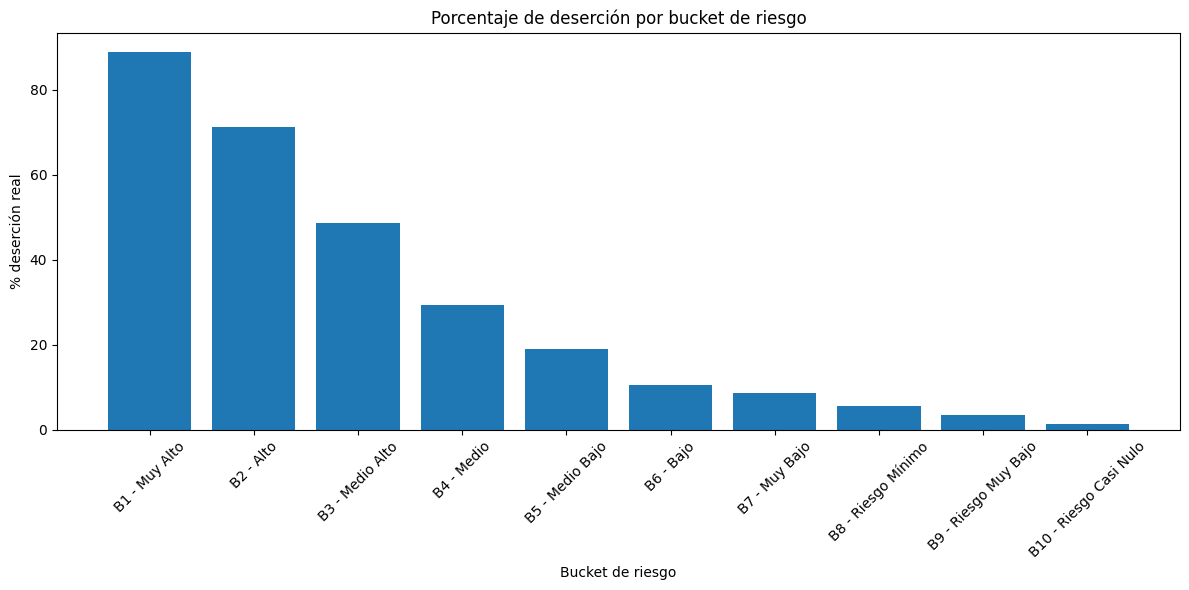

In [42]:
# =========================
# GRÁFICA % DESERCIÓN
# =========================

plt.figure(figsize=(12,6))

plt.bar(
    tabla_eficiencia["bucket_riesgo"],
    tabla_eficiencia["tasa_desercion_real_%"]
)

plt.title("Porcentaje de deserción por bucket de riesgo")
plt.xlabel("Bucket de riesgo")
plt.ylabel("% deserción real")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
!pip install shap

import shap

In [ ]:
# =========================
# SHAP VALUES - XGBOOST
# =========================

explainer_xgb = shap.TreeExplainer(best_xgb)

shap_values_xgb = explainer_xgb.shap_values(X_test)

In [ ]:
# =========================
# TABLA SHAP - XGBOOST
# =========================

tabla_shap_xgb = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": np.abs(shap_values_xgb).mean(axis=0)
}).sort_values(
    by="mean_abs_shap",
    ascending=False
)

tabla_shap_xgb.head(20)

In [ ]:
# Exportar tabla SHAP
tabla_shap_xgb.to_csv(
    "tabla_shap_values_xgboost.csv",
    index=False
)

print("Tabla SHAP exportada correctamente.")

In [ ]:
# =========================
# GRÁFICO SHAP
# =========================

shap.summary_plot(shap_values_xgb, X_test)